### Accident Severity Prediction

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

#### Load Dataset

In [ ]:
# Read the dataset
Part_A_ds = pd.read_csv("../Accident-Severity Dataset/US_Accidents_March23.csv")

In [ ]:
# Load the dataset - first 5 rows
Part_A_ds.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [ ]:
# Load the dataset - last 5 rows
Part_A_ds.tail()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7728389,A-7777757,Source1,2,2019-08-23 18:03:25,2019-08-23 18:32:01,34.00248,-117.37936,33.99888,-117.37094,0.543,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,A-7777758,Source1,2,2019-08-23 19:11:30,2019-08-23 19:38:23,32.76696,-117.14806,32.76555,-117.15363,0.338,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,A-7777759,Source1,2,2019-08-23 19:00:21,2019-08-23 19:28:49,33.77545,-117.84779,33.77740,-117.85727,0.561,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,A-7777760,Source1,2,2019-08-23 19:00:21,2019-08-23 19:29:42,33.99246,-118.40302,33.98311,-118.39565,0.772,...,False,False,False,False,False,False,Day,Day,Day,Day
7728393,A-7777761,Source1,2,2019-08-23 18:52:06,2019-08-23 19:21:31,34.13393,-117.23092,34.13736,-117.23934,0.537,...,False,False,False,False,False,False,Day,Day,Day,Day


#### Analysing the dataset

In [ ]:
# Observe the datasets size and structure
Part_A_ds.shape

(7728394, 46)

In [ ]:
Part_A_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [ ]:
Part_A_ds.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [ ]:
Part_A_ds.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


#### Data Cleaning

In [ ]:
# Checking for missing values
Part_A_ds.isnull().sum().sort_values(ascending=False)

,0
End_Lng,3402762
End_Lat,3402762
Precipitation(in),2203586
Wind_Chill(F),1999019
Wind_Speed(mph),571233
Visibility(mi),177098
Wind_Direction,175206
Humidity(%),174144
Weather_Condition,173459
Temperature(F),163853


In [ ]:
# The percentage of the top features with missing values
total_percent = Part_A_ds.isnull().sum().sort_values(ascending=False)
print(total_percent/len(Part_A_ds)*100)

End_Lng                  44.029355
End_Lat                  44.029355
Precipitation(in)        28.512858
Wind_Chill(F)            25.865904
Wind_Speed(mph)           7.391355
Visibility(mi)            2.291524
Wind_Direction            2.267043
Humidity(%)               2.253301
Weather_Condition         2.244438
Temperature(F)            2.120143
Pressure(in)              1.820288
Weather_Timestamp         1.555666
Sunrise_Sunset            0.300787
Civil_Twilight            0.300787
Astronomical_Twilight     0.300787
Nautical_Twilight         0.300787
Airport_Code              0.292881
Street                    0.140637
Timezone                  0.101030
Zipcode                   0.024779
City                      0.003274
Description               0.000065
ID                        0.000000
Distance(mi)              0.000000
Start_Lng                 0.000000
Source                    0.000000
Severity                  0.000000
Start_Time                0.000000
End_Time            

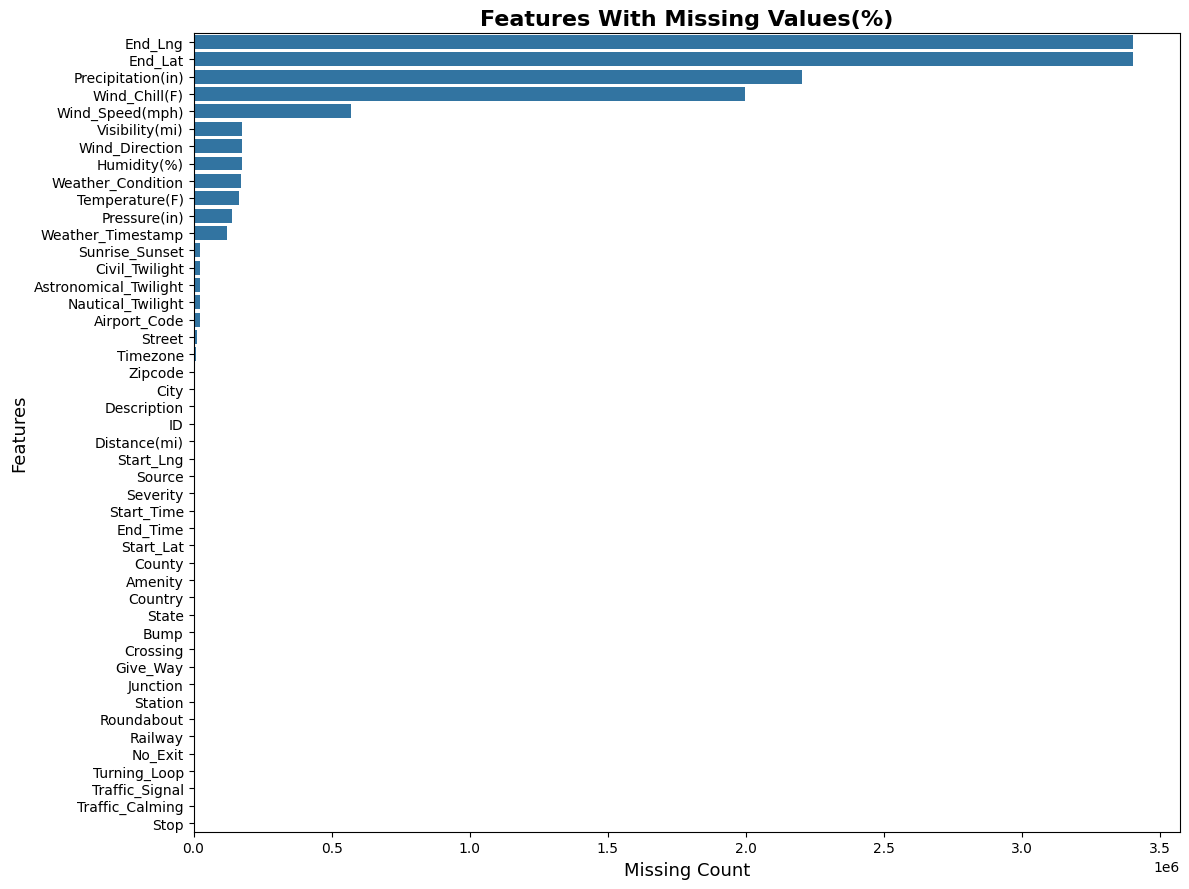

In [ ]:
# Visualising the missing values in the dataset
plt.figure(figsize= (12, 9))
sns.barplot(x=total_percent.values, y=total_percent.index)
plt.title("Features With Missing Values(%)", fontsize=16, fontweight="bold")
plt.xlabel("Missing Count", fontsize=13)
plt.ylabel("Features", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#Features - "End_Lng" & "End_Lat" hold high percentage of null values.
#Imputing values in them will be unrealistic, thus, these columns will be dropped.

Part_A_ds = Part_A_ds.drop(columns=["End_Lng", "End_Lat"])

In [ ]:
#Features: "Precipitation(in)", "Wind_Chill(F)", & "Wind_Speed(mph)".
#They hold numerical values, it would be most appropriate to impute them using median,
#Since dropping the columns or rows will impact the dataset, causing to lose too much valuable data.
numeric_A_impute = ["Precipitation(in)","Wind_Chill(F)", "Wind_Speed(mph)"]

Part_A_ds[numeric_A_impute] = Part_A_ds[numeric_A_impute].fillna(Part_A_ds[numeric_A_impute].median())

In [ ]:
#Features: "Visibility(mi)", "Humidity(%)", "Temperature(F)", & "Pressure(in)".
#They hold numerical values, to tackle the missing values median will be used to impute the missing rows.
numeric_B_impute = ["Visibility(mi)", "Humidity(%)", "Temperature(F)", "Pressure(in)"]

Part_A_ds[numeric_B_impute] = Part_A_ds[numeric_B_impute].fillna(Part_A_ds[numeric_B_impute].median())

In [ ]:
#Features: "Wind_Direction", "Weather_Condition", "Sunrise_Sunset", "Civil_Twilight", "Astronomical_Twilight", "Nautical_Twilight", & "Airport_Code".
#These are categorical features, to tackle the missing values mode will be used to impute the missing rows.
categoric_impute = ["Wind_Direction", "Weather_Condition", "Sunrise_Sunset", "Civil_Twilight", "Astronomical_Twilight", "Nautical_Twilight", "Airport_Code"]

Part_A_ds[categoric_impute] = Part_A_ds[categoric_impute].fillna(Part_A_ds[categoric_impute].mode().iloc[0])

In [ ]:
#Features: "Weather_Timestamp", "Street", "Timezone ", "Zipcode", "City", & "Description".
#The rows from the features will be dropped as they are specific and imputing them with either mode, medium, or mean wont be suitable.

Part_A_ds = Part_A_ds.dropna(subset=["Weather_Timestamp", "Street", "Timezone", "Zipcode", "City", "Description"])

In [ ]:
#Checking for any remaining null values
Part_A_ds.isnull().sum().sort_values(ascending=False)

,0
ID,0
Source,0
Severity,0
Start_Time,0
End_Time,0
Start_Lat,0
Start_Lng,0
Distance(mi),0
Description,0
Street,0


In [ ]:
#Checking for any duplicate values
Part_A_ds.duplicated().sum()

np.int64(0)

#### Exploratory Data Analysis

##### Univariate

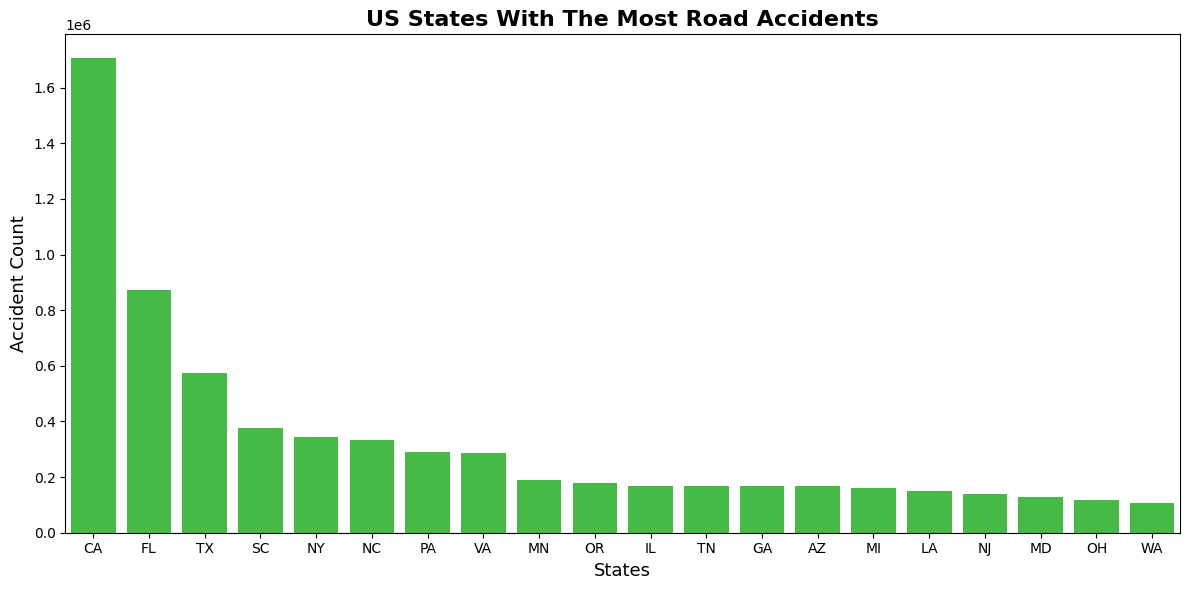

In [ ]:
# Top US States with the most road accidents
top_states = Part_A_ds["State"].value_counts()

top_20_states = top_states.head(20)
plt.figure(figsize= (12, 6))
sns.barplot(x=top_20_states.index, y=top_20_states.values, color="limegreen")
plt.title("US States With The Most Road Accidents", fontsize=16, fontweight="bold")
plt.xlabel("States", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.show()

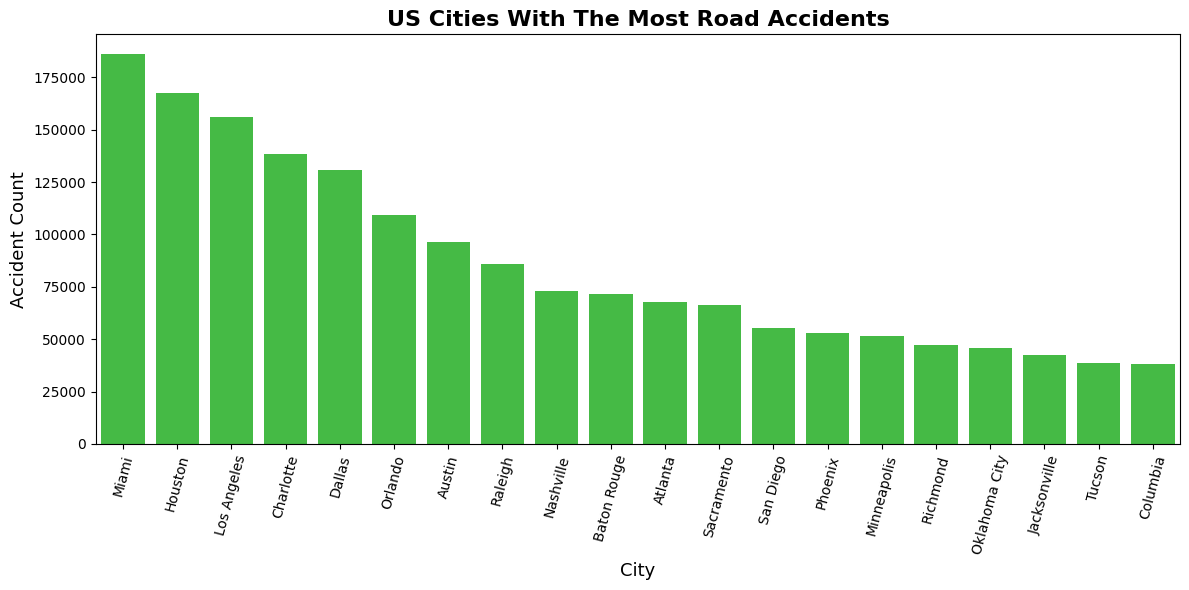

In [ ]:
# Top US Cities with the most road accidents
top_city = Part_A_ds["City"].value_counts()

top_20_city = top_city.head(20)
plt.figure(figsize= (12, 6))
sns.barplot(x=top_20_city.index, y=top_20_city.values, color="limegreen")
plt.title("US Cities With The Most Road Accidents", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

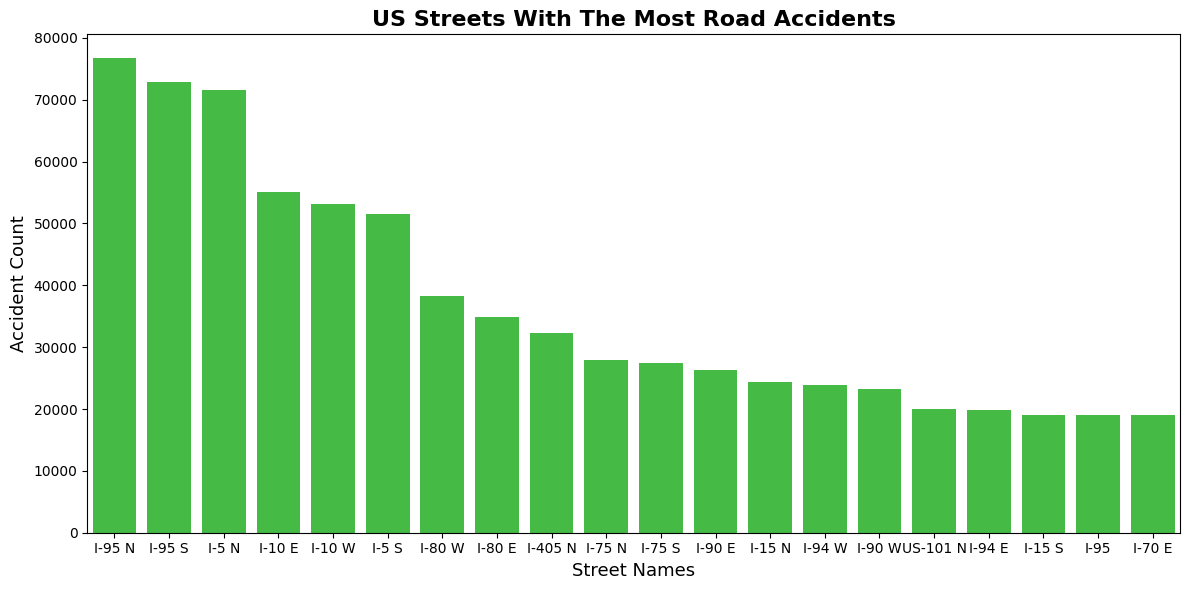

In [ ]:
# Top US Streets with the most road accidents
top_street = Part_A_ds["Street"].value_counts()

top_20_street = top_street.head(20)
plt.figure(figsize= (12, 6))
sns.barplot(x=top_20_street.index, y=top_20_street.values, color="limegreen")
plt.title("US Streets With The Most Road Accidents", fontsize=16, fontweight="bold")
plt.xlabel("Street Names", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Formatting Feature: "Start_Time" into datetime format
Part_A_ds.Start_Time = pd.to_datetime(Part_A_ds.Start_Time, format="mixed")

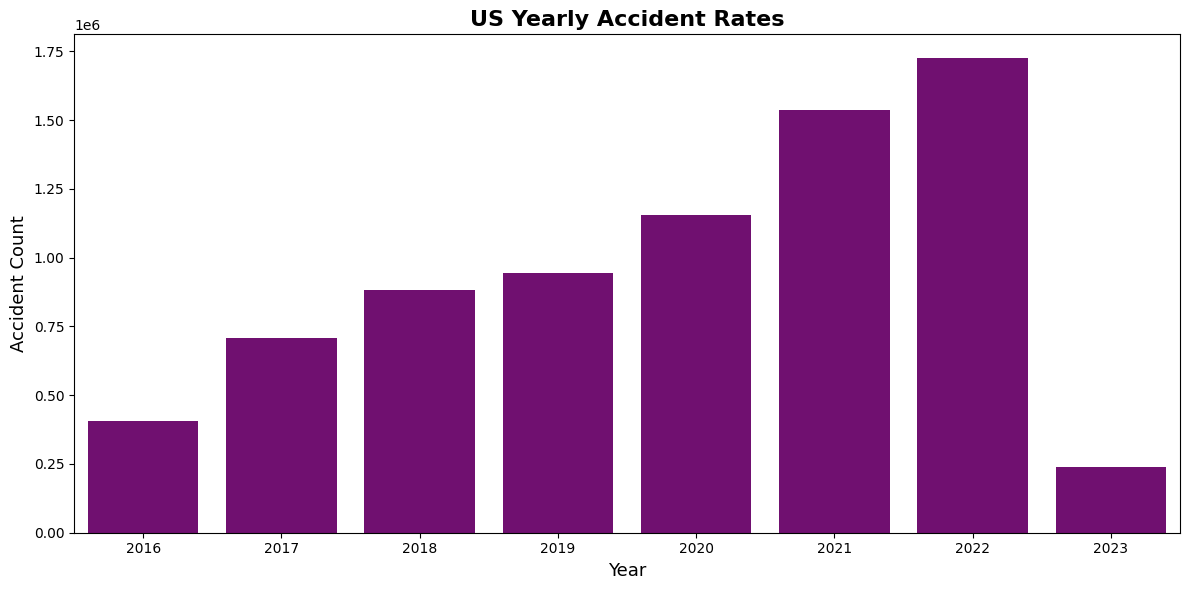

In [ ]:
# Yearly road accident rates
yearly_rates = Part_A_ds["Start_Time"].dt.year
yearly_rates = pd.DataFrame(yearly_rates.value_counts()).sort_values(by=["Start_Time"])

plt.figure(figsize= (12, 6))
sns.barplot(x=yearly_rates.index, y=yearly_rates["count"], color="purple")
plt.title("US Yearly Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.show()

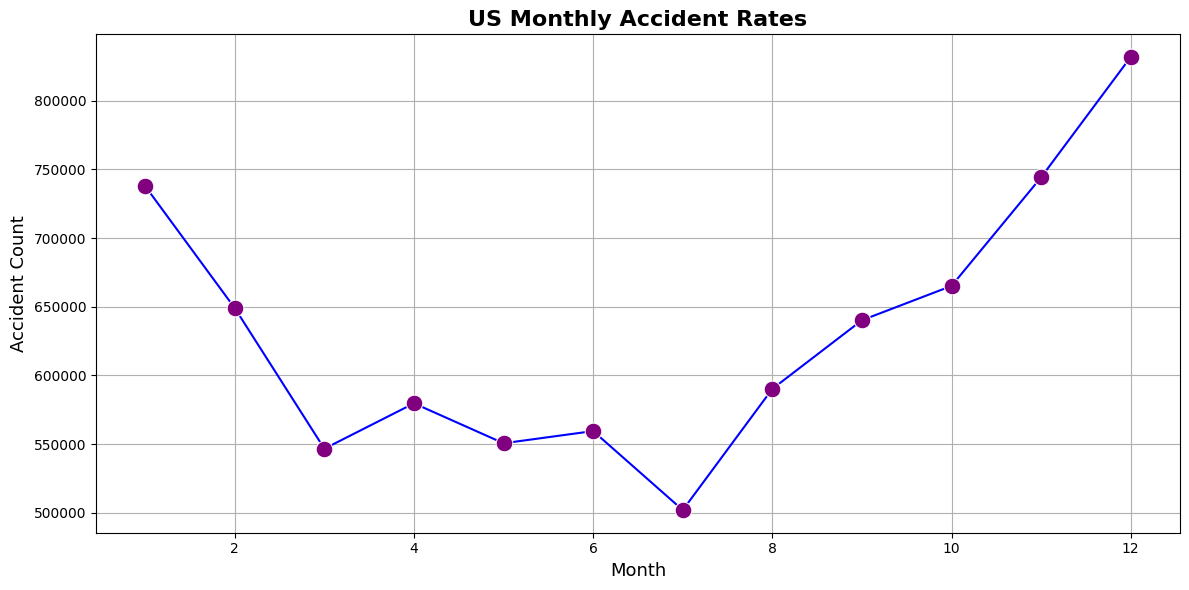

In [ ]:
# Monthly road accident rates
monthly_rates = Part_A_ds["Start_Time"].dt.month
monthly_rates = pd.DataFrame(monthly_rates.value_counts()).sort_values(by=["Start_Time"])

plt.figure(figsize= (12, 6))
sns.lineplot(x=monthly_rates.index, y=monthly_rates["count"], marker="o", markersize=12, markerfacecolor="purple", color="blue")
plt.title("US Monthly Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.grid()
plt.tight_layout()
plt.show()

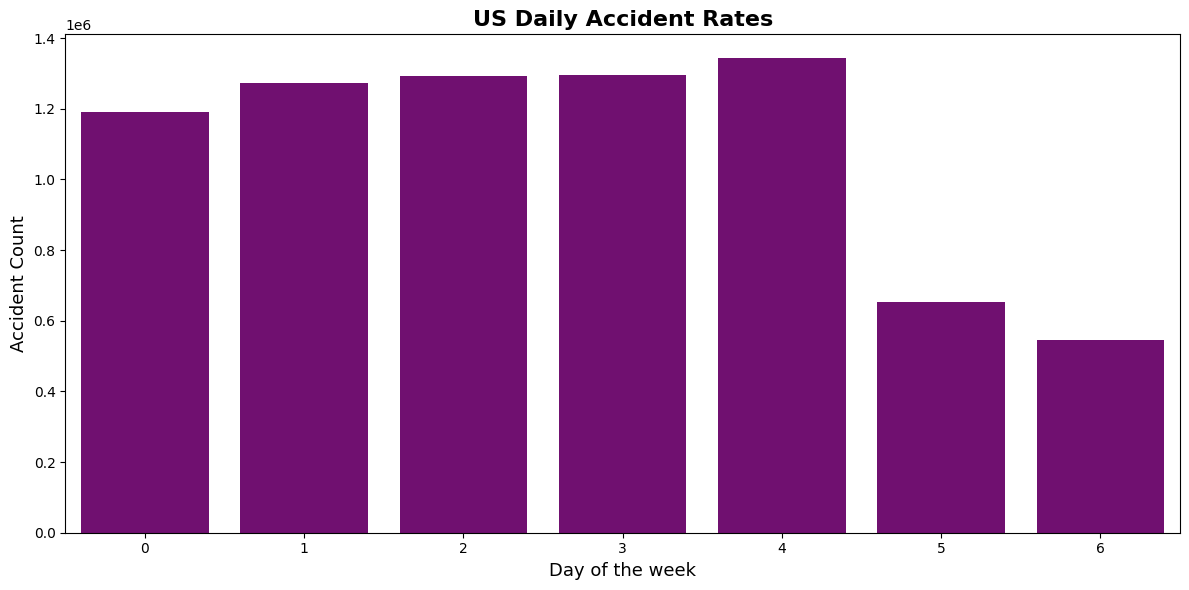

In [ ]:
# Daily road accident rates
daily_rates = Part_A_ds["Start_Time"].dt.dayofweek
daily_rates = pd.DataFrame(daily_rates.value_counts()).sort_values(by=["Start_Time"])

plt.figure(figsize= (12, 6))
sns.barplot(x=daily_rates.index, y=daily_rates["count"], color="purple")
plt.title("US Daily Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Day of the week", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.show()

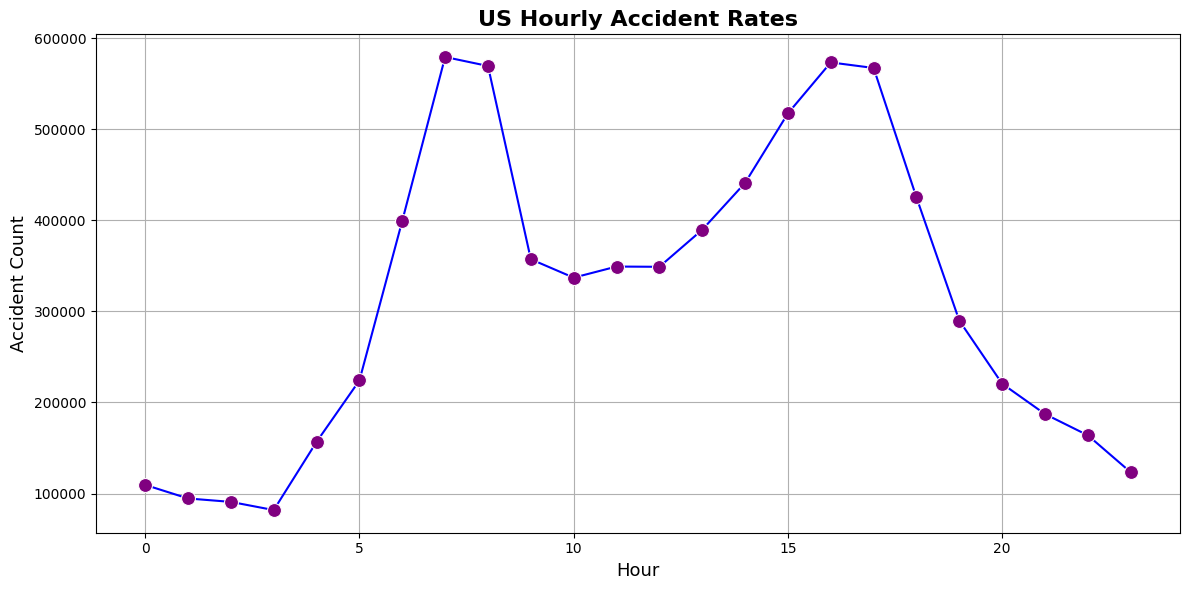

In [ ]:
# Hourly road accident rates
hourly_rates = Part_A_ds["Start_Time"].dt.hour
hourly_rates = pd.DataFrame(hourly_rates.value_counts()).sort_values(by=["Start_Time"])

plt.figure(figsize= (12, 6))
sns.lineplot(x=hourly_rates.index, y=hourly_rates["count"], marker="o", markersize=10, markerfacecolor="purple", color="blue")
plt.title("US Hourly Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Hour", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.grid()
plt.tight_layout()
plt.show()

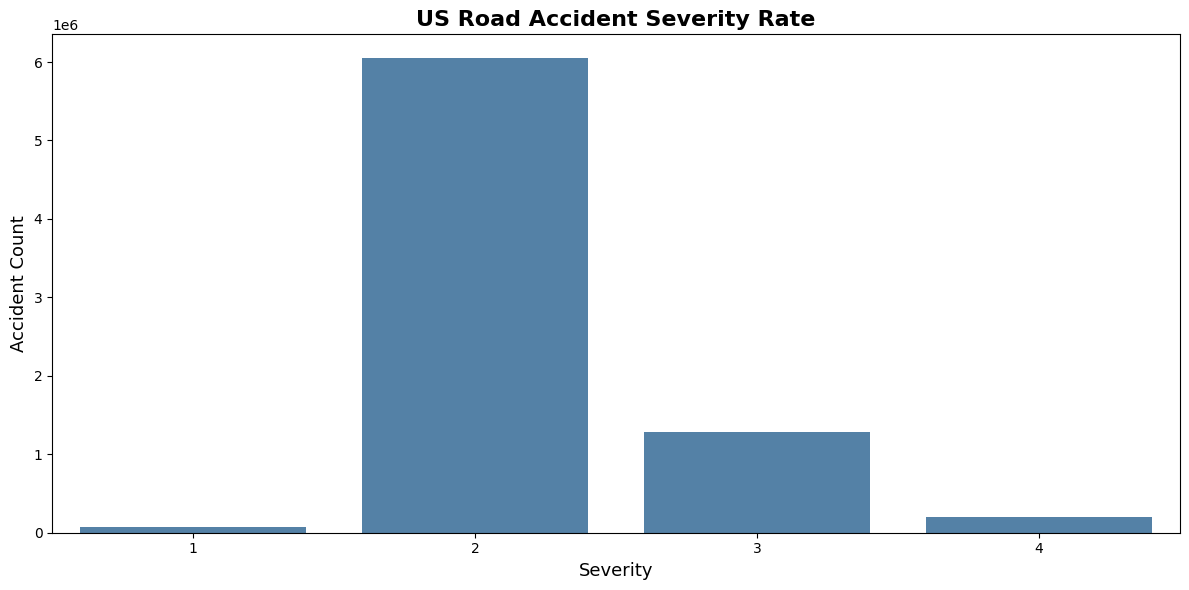

In [ ]:
# Top US Streets with the most road accidents
accident_severe = Part_A_ds["Severity"].value_counts()

plt.figure(figsize= (12, 6))
sns.barplot(x=accident_severe.index, y=accident_severe.values, color="steelblue")
plt.title("US Road Accident Severity Rate", fontsize=16, fontweight="bold")
plt.xlabel("Severity", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.show()

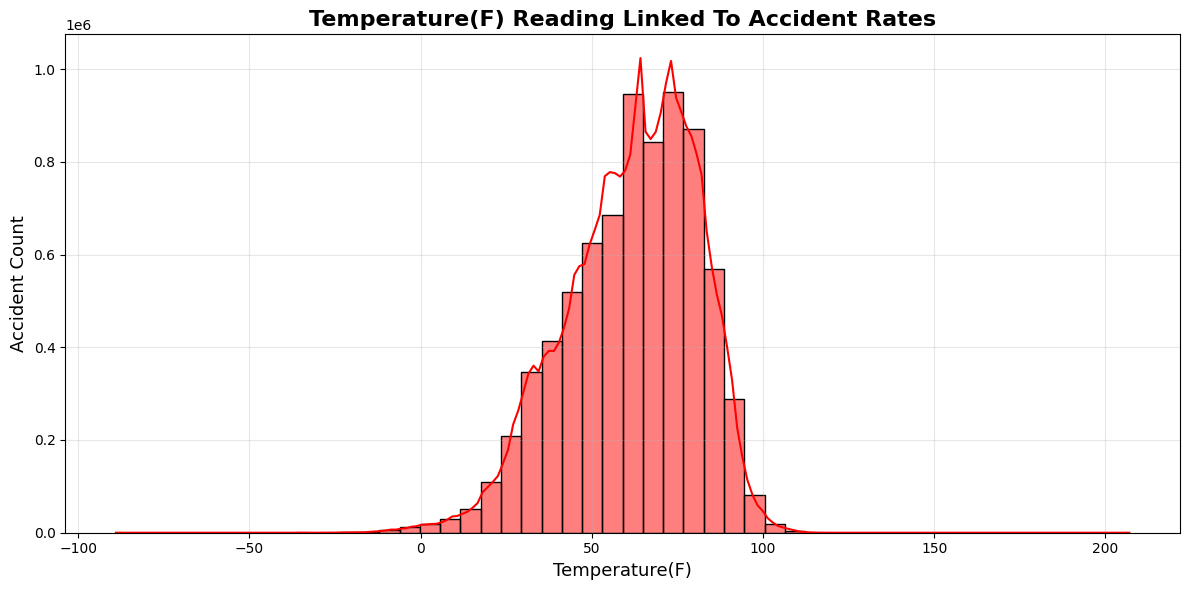

In [ ]:
# At what temperature do most US road accidents take place
temp_reading = Part_A_ds["Temperature(F)"]

plt.figure(figsize= (12, 6))
sns.histplot(data=temp_reading, kde=True, bins=50, color="red")
plt.title("Temperature(F) Reading Linked To Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Temperature(F)", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

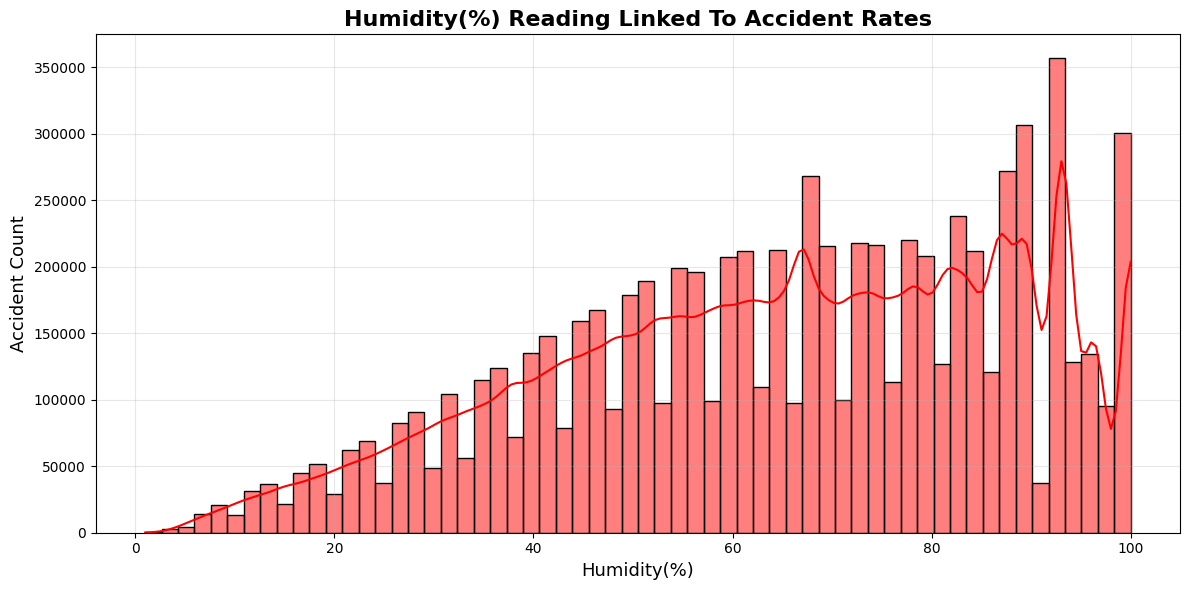

In [ ]:
# At what humidity level do most US road accidents take place
humid_reading = Part_A_ds["Humidity(%)"]

plt.figure(figsize= (12, 6))
sns.histplot(data=humid_reading, kde=True, bins=60, color="red")
plt.title("Humidity(%) Reading Linked To Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Humidity(%)", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

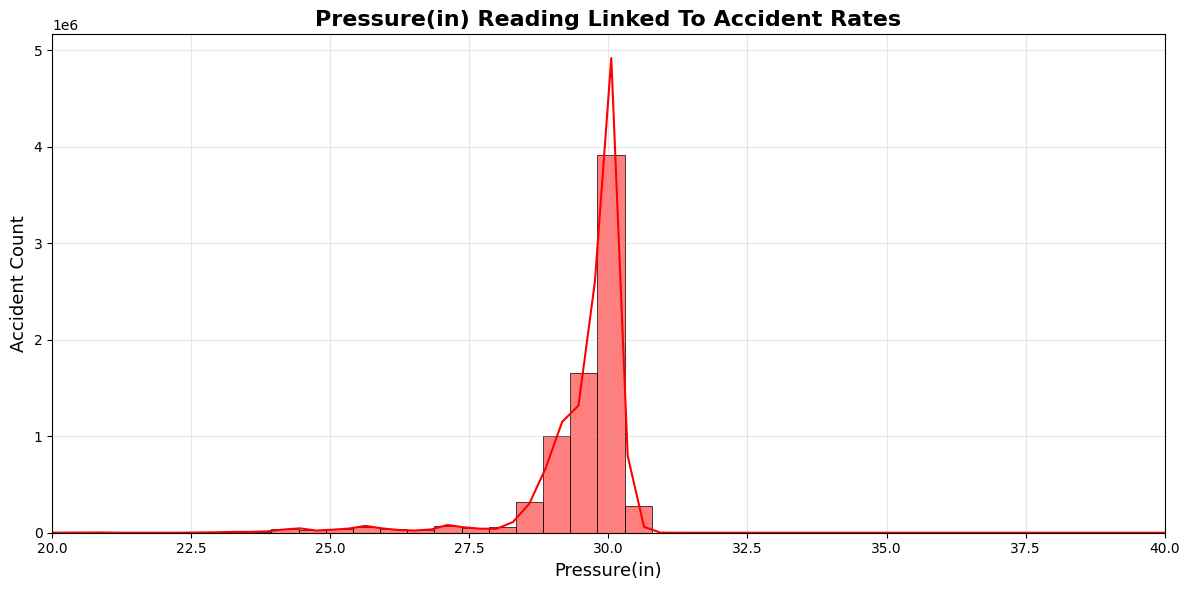

In [ ]:
# At what pressure level do most US road accidents take place
pressure_reading = Part_A_ds["Pressure(in)"]

plt.figure(figsize= (12, 6))
sns.histplot(data=pressure_reading, kde=True, bins=120, color="red")
plt.title("Pressure(in) Reading Linked To Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Pressure(in)", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.xlim(20, 40)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

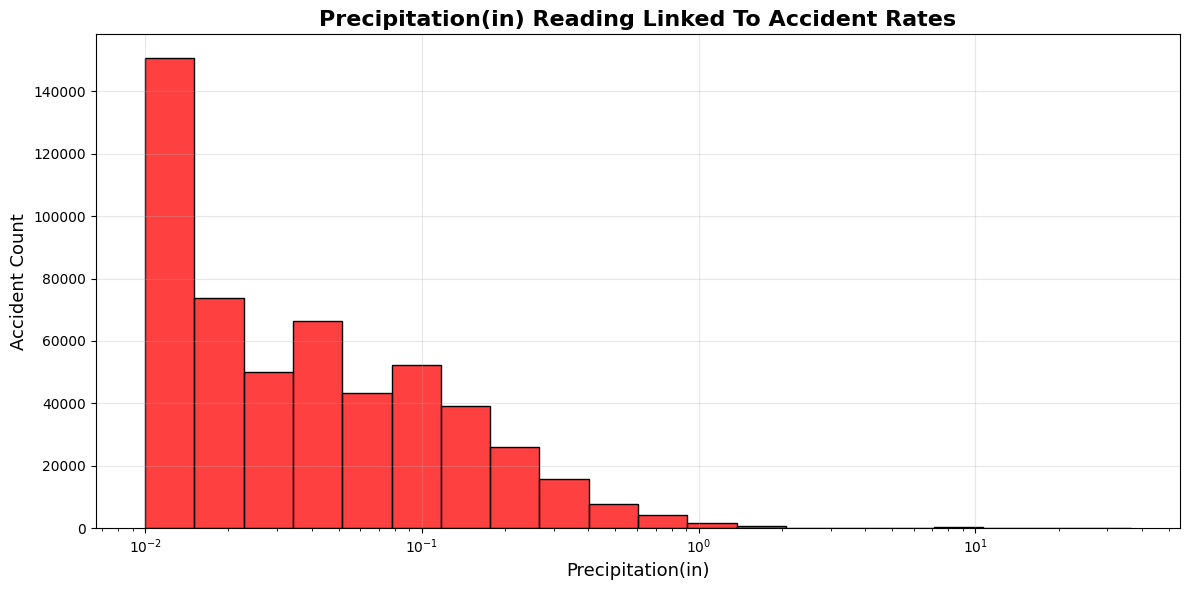

In [ ]:
# At what precipitation level do most US road accidents take place
precipit_reading = Part_A_ds["Precipitation(in)"]

plt.figure(figsize= (12, 6))
sns.histplot(data=precipit_reading, bins=20, log_scale=True, color="red")
plt.title("Precipitation(in) Reading Linked To Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Precipitation(in)", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

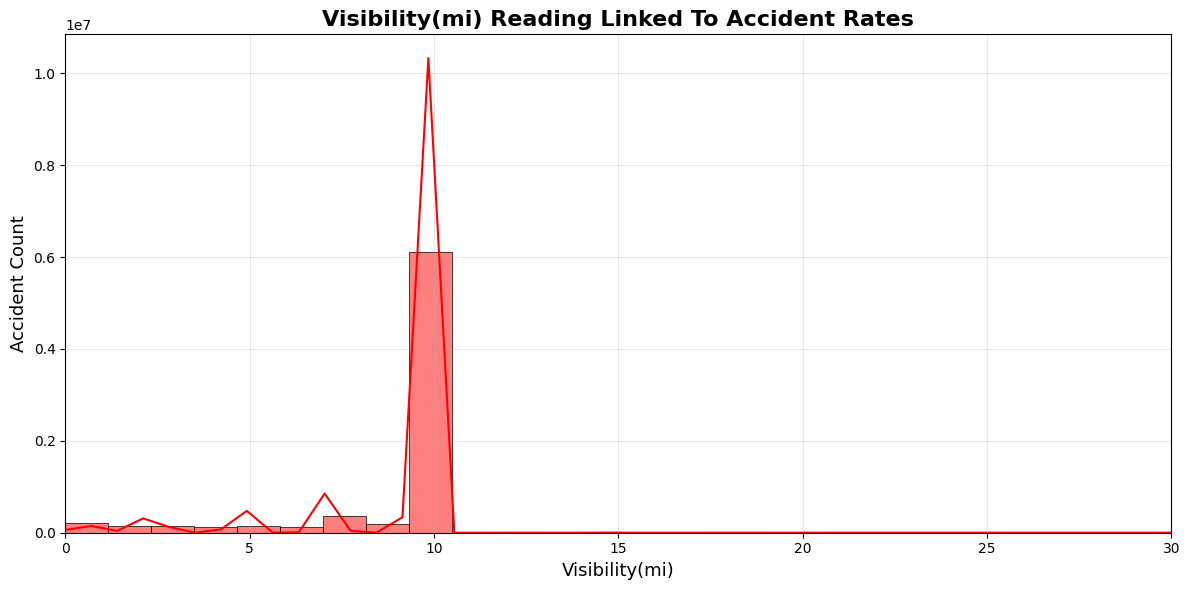

In [ ]:
# At what visibility level do most US road accidents take place
visib_reading = Part_A_ds["Visibility(mi)"]

plt.figure(figsize= (12, 6))
sns.histplot(data=visib_reading, kde=True, bins=120, color="red")
plt.title("Visibility(mi) Reading Linked To Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Visibility(mi)", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.xlim(0, 30)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

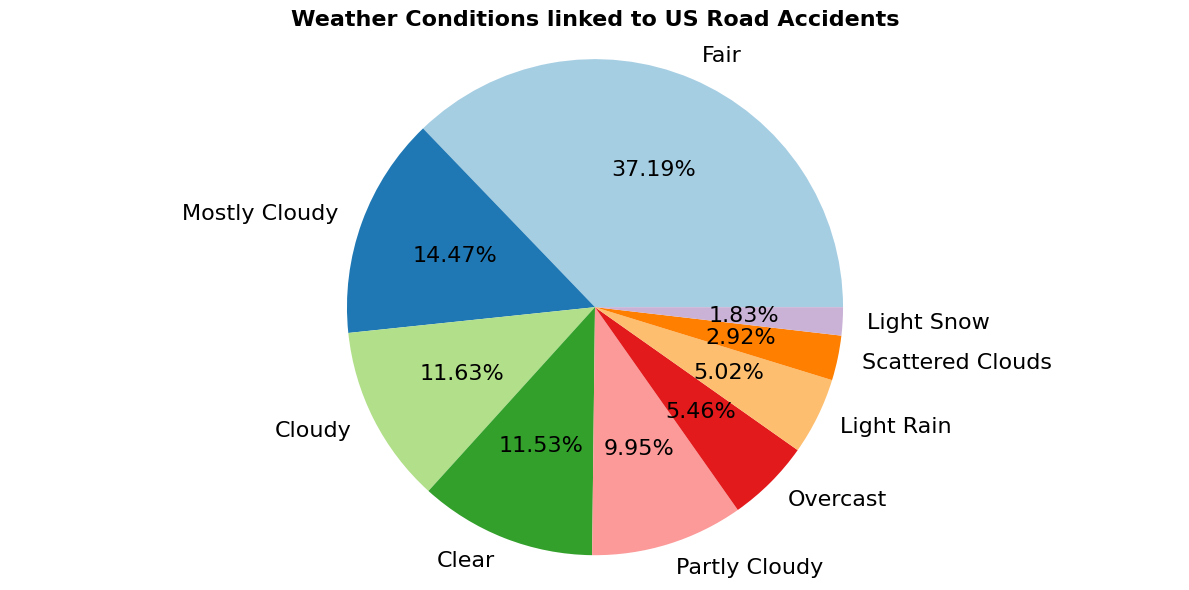

In [ ]:
# At what weather condition do most US road accidents take place
weather_condit = Part_A_ds["Weather_Condition"].value_counts().head(9)

plt.figure(figsize= (12, 6))
plt.pie(weather_condit, labels=weather_condit.index, colors=sns.color_palette("Paired"), autopct="%1.2f%%", textprops={"fontsize":16})
plt.title("Weather Conditions linked to US Road Accidents", fontsize=16, fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

##### Bivariate

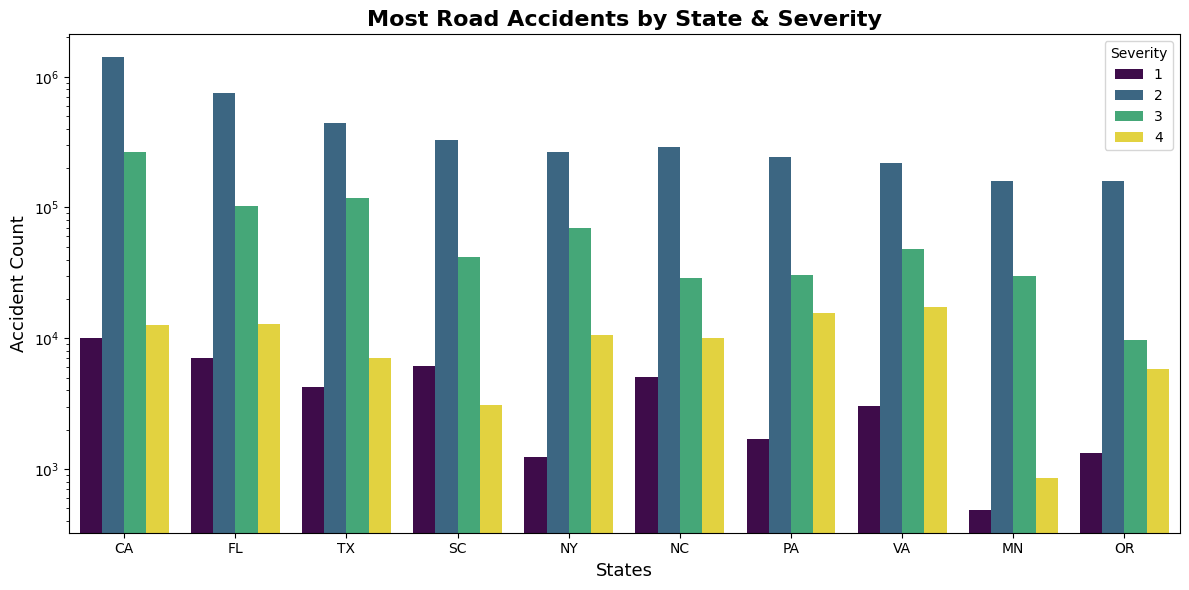

In [ ]:
# Most Road Accidents by State & Severity
states_v_severe = Part_A_ds["State"].value_counts().head(10).index

plt.figure(figsize= (12, 6))
sns.countplot(data=Part_A_ds, x="State", hue="Severity", order=states_v_severe, palette="viridis")
plt.title("Most Road Accidents by State & Severity", fontsize=16, fontweight="bold")
plt.xlabel("States", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.yscale("log")
plt.tight_layout()
plt.show()

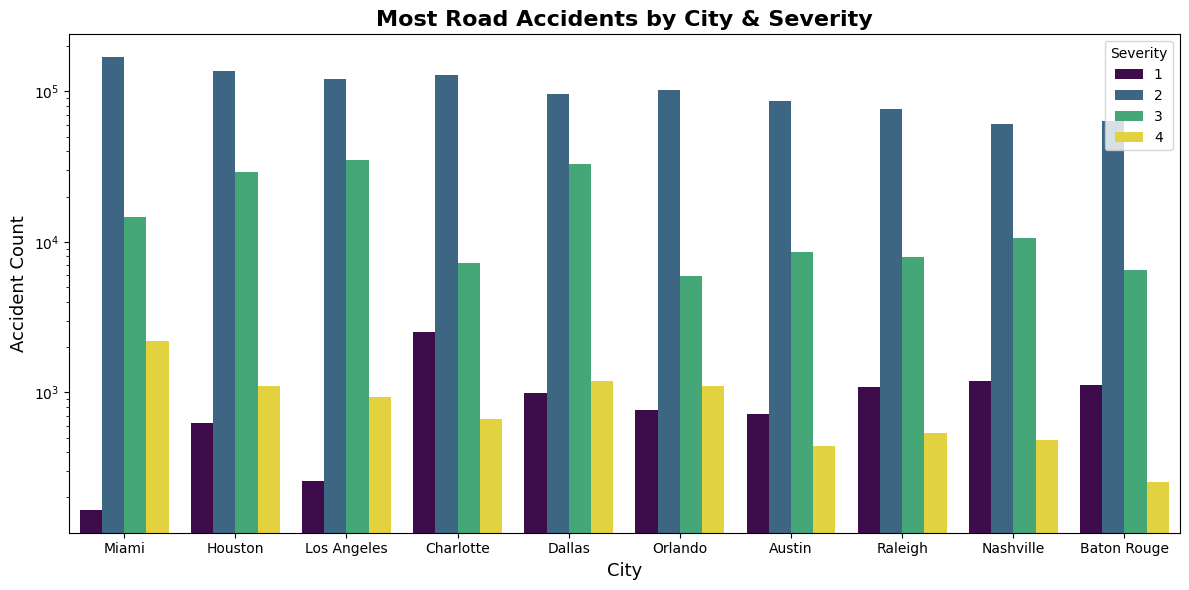

In [ ]:
# Most Road Accidents by City & Severity
city_v_severe = Part_A_ds["City"].value_counts().head(10).index

plt.figure(figsize= (12, 6))
sns.countplot(data=Part_A_ds, x="City", hue="Severity", order=city_v_severe, palette="viridis")
plt.title("Most Road Accidents by City & Severity", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.yscale("log")
plt.tight_layout()
plt.show()

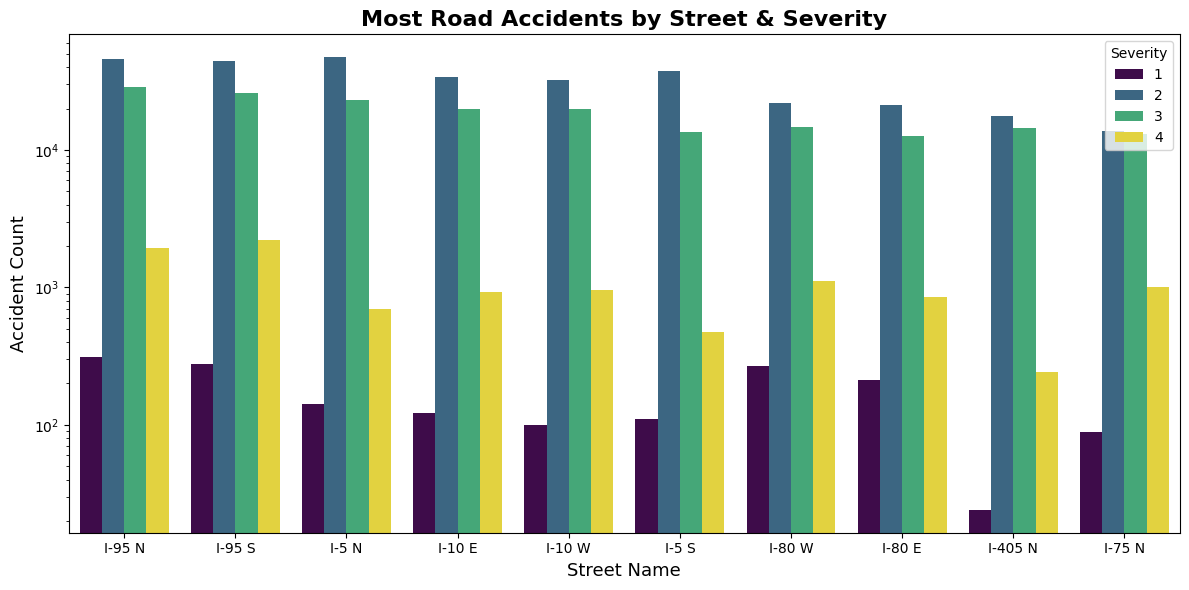

In [ ]:
# Most Road Accidents by Street & Severity
street_v_severe = Part_A_ds["Street"].value_counts().head(10).index

plt.figure(figsize= (12, 6))
sns.countplot(data=Part_A_ds, x="Street", hue="Severity", order=street_v_severe, palette="viridis")
plt.title("Most Road Accidents by Street & Severity", fontsize=16, fontweight="bold")
plt.xlabel("Street Name", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.yscale("log")
plt.tight_layout()
plt.show()

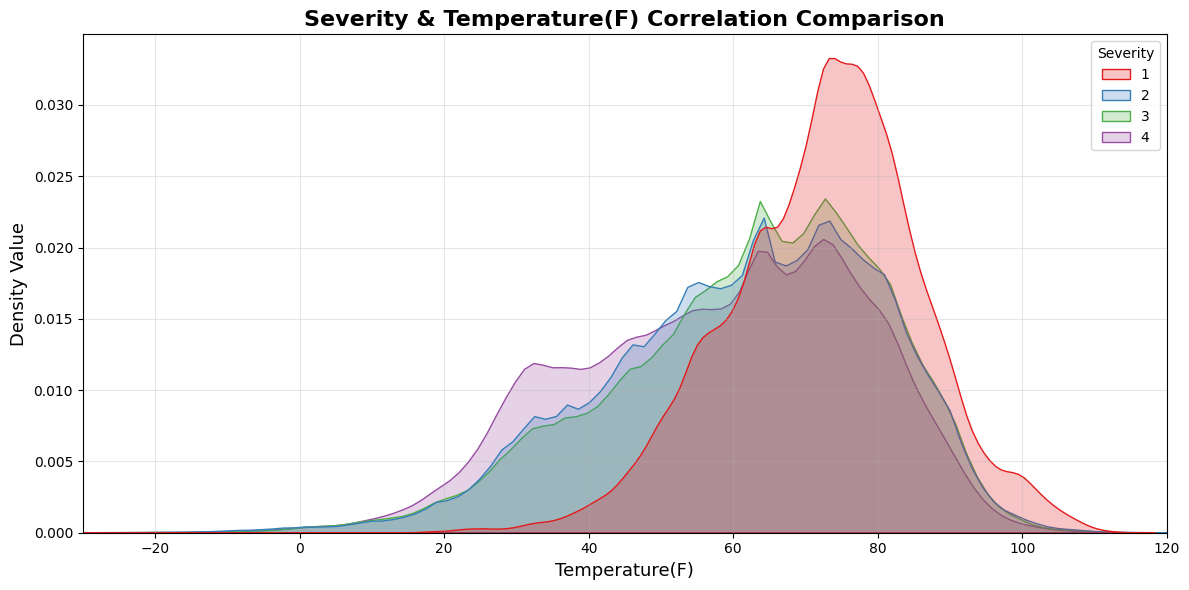

In [ ]:
# Visualising the correlation between temperature + severity on how it affects US road accidents
plt.figure(figsize= (12, 6))
sns.kdeplot(data=Part_A_ds, x= "Temperature(F)", hue= "Severity", palette="Set1", common_norm=False, fill=True)
plt.title("Severity & Temperature(F) Correlation Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Temperature(F)", fontsize=13)
plt.ylabel("Density Value", fontsize=13)
plt.xlim(-30, 120)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

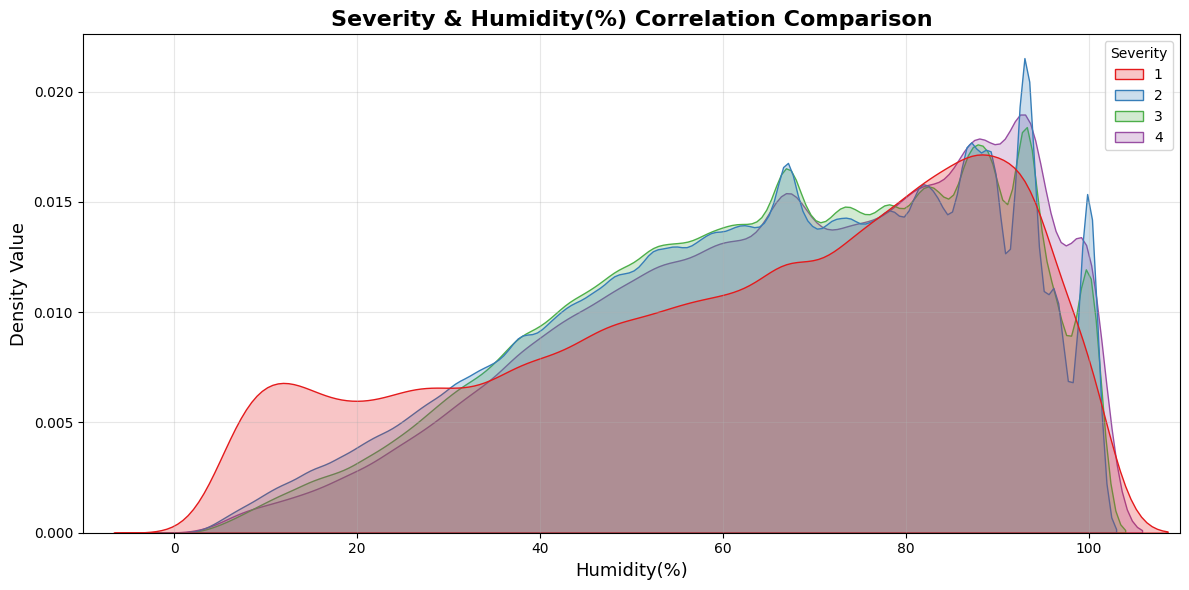

In [ ]:
# Visualising the correlation between humidity + severity on how it affects US road accidents
plt.figure(figsize= (12, 6))
sns.kdeplot(data=Part_A_ds, x= "Humidity(%)", hue= "Severity", palette="Set1", common_norm=False, fill=True)
plt.title("Severity & Humidity(%) Correlation Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Humidity(%)", fontsize=13)
plt.ylabel("Density Value", fontsize=13)
plt.xlim(-10, 110)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

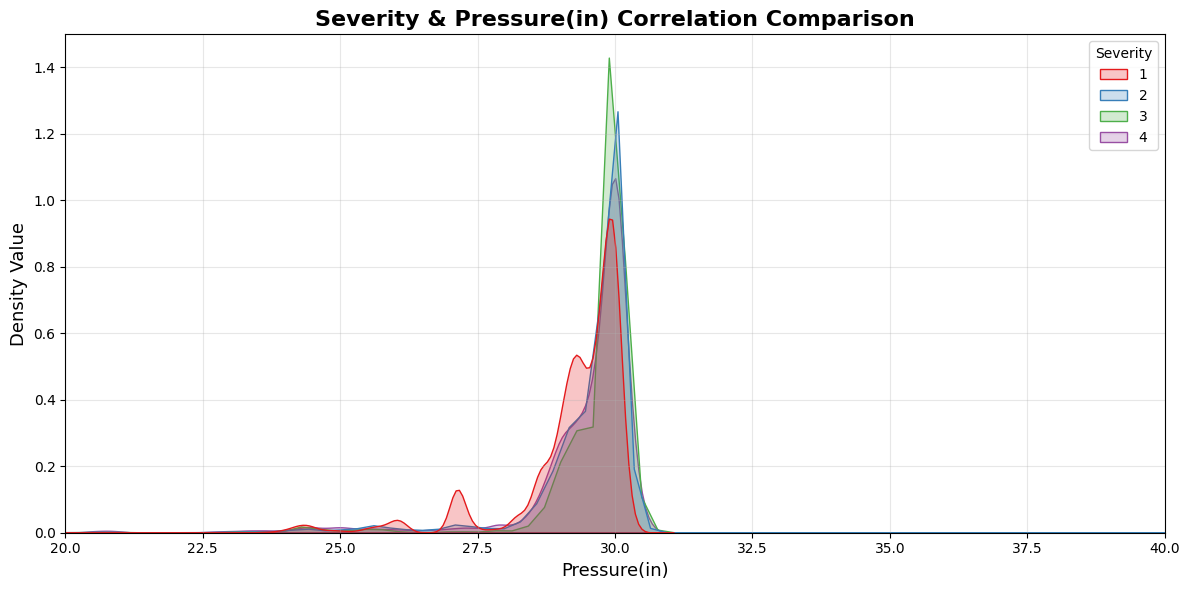

In [ ]:
# Visualising the correlation between pressure + severity on how it affects US road accidents
plt.figure(figsize= (12, 6))
sns.kdeplot(data=Part_A_ds, x= "Pressure(in)", hue= "Severity", palette="Set1", common_norm=False, fill=True)
plt.title("Severity & Pressure(in) Correlation Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Pressure(in)", fontsize=13)
plt.ylabel("Density Value", fontsize=13)
plt.xlim(20, 40)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

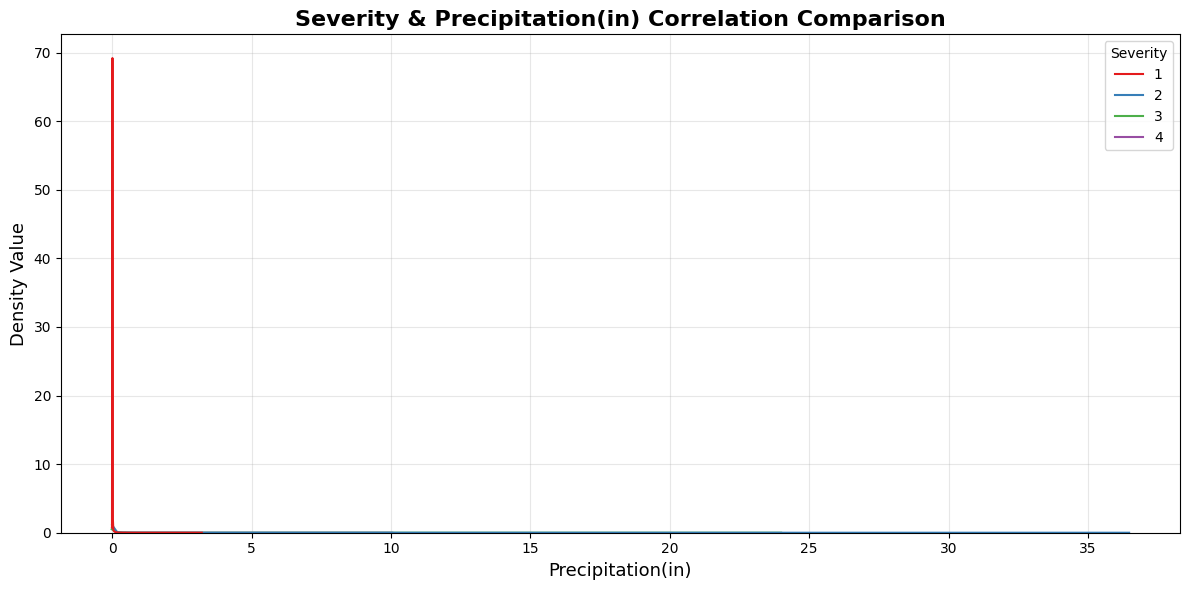

In [ ]:
# Visualising the correlation between precipitation + severity on how it affects US road accidents
plt.figure(figsize= (12, 6))
sns.kdeplot(data=Part_A_ds, x= "Precipitation(in)", hue= "Severity", palette="Set1", common_norm=False)
plt.title("Severity & Precipitation(in) Correlation Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Precipitation(in)", fontsize=13)
plt.ylabel("Density Value", fontsize=13)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

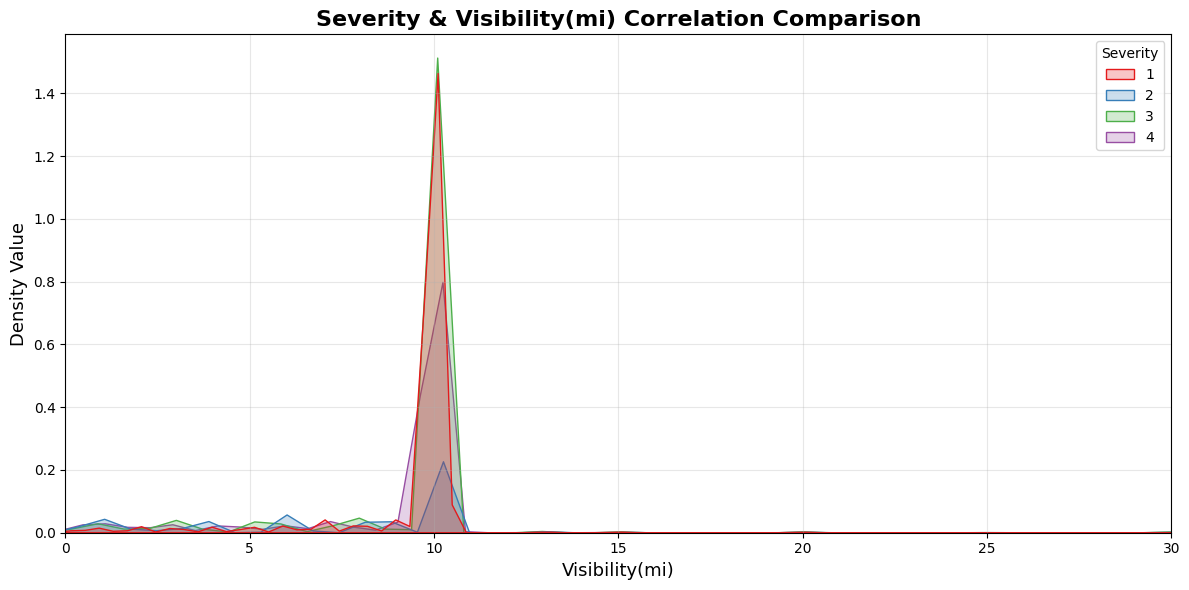

In [ ]:
# Visualising the correlation between visibility + severity on how it affects US road accidents
plt.figure(figsize= (12, 6))
sns.kdeplot(data=Part_A_ds, x= "Visibility(mi)", hue= "Severity", palette="Set1", common_norm=False, fill=True)
plt.title("Severity & Visibility(mi) Correlation Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Visibility(mi)", fontsize=13)
plt.ylabel("Density Value", fontsize=13)
plt.xlim(0, 30)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

##### Multivariate

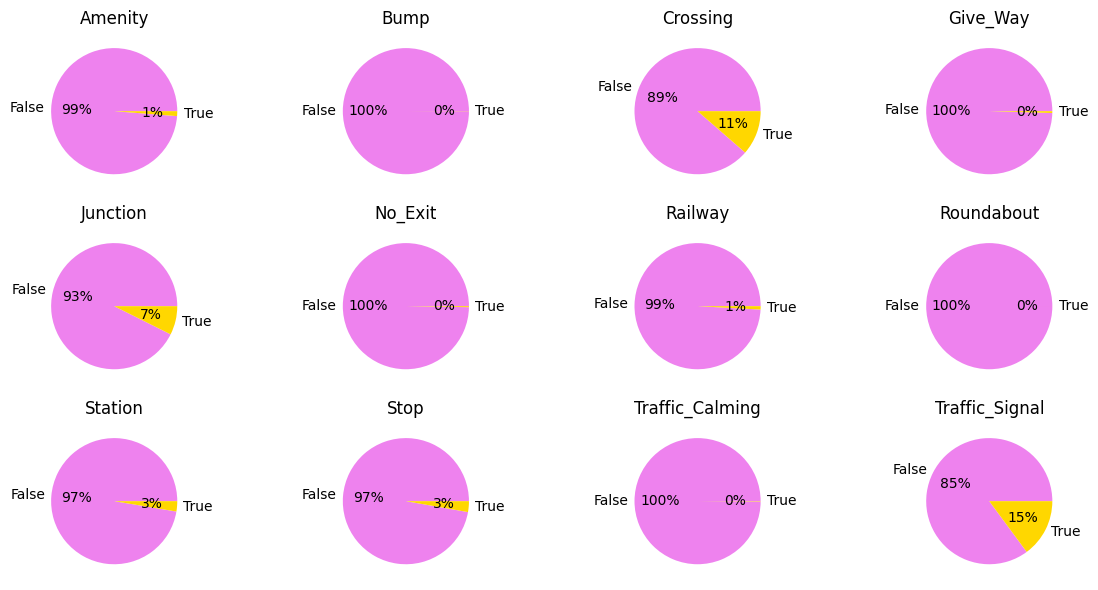

In [ ]:
# Visualising various location based factors that contribute to accidents
factor_based_feat = ["Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal"]
fig, ax = plt.subplots(figsize=(12, 6), ncols=4, nrows=3, sharex=True, sharey=True)
ax_flattening = ax.flatten()

for n, feature in enumerate(factor_based_feat):
    multi_pie_diagram = ax_flattening[n]
    multi_pie_diagram_val = Part_A_ds[feature].value_counts()
    multi_pie_diagram_color = ["violet", "gold"]
    multi_pie_diagram.pie(multi_pie_diagram_val, labels=multi_pie_diagram_val.index, autopct="%1.0f%%", colors=multi_pie_diagram_color)
    multi_pie_diagram.set_title(feature)
plt.tight_layout()
plt.show()

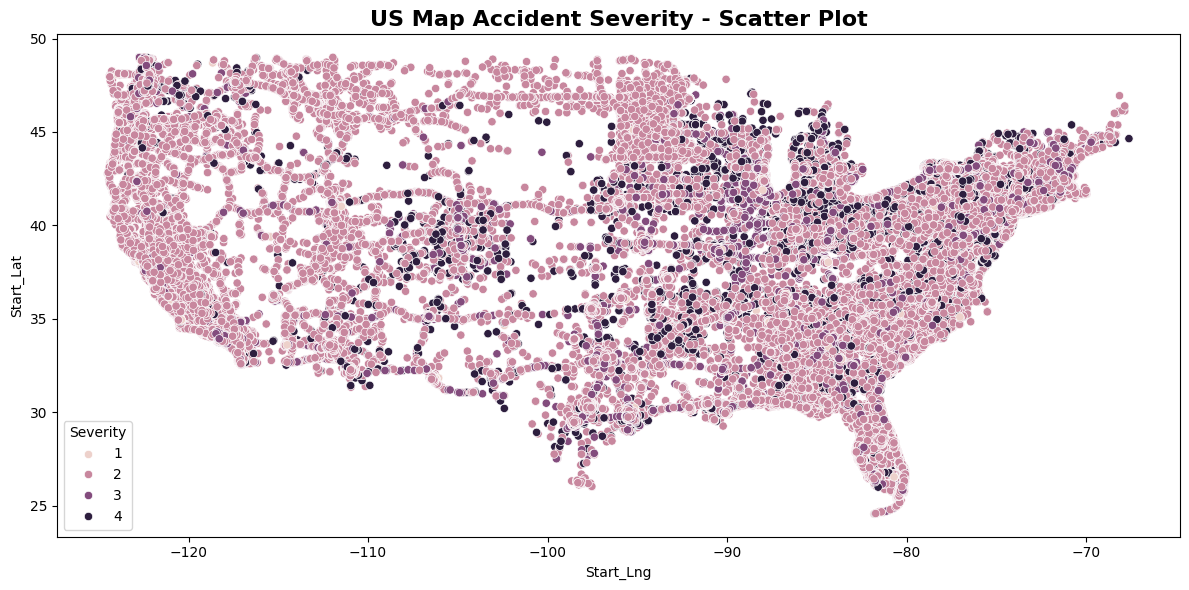

In [ ]:
# US Map - Accident scatter plot by Start Lng, Start Lat & Severity
plt.figure(figsize= (12, 6))
sns.scatterplot(data=Part_A_ds.sample(1000000), x="Start_Lng", y="Start_Lat", hue="Severity")
plt.title("US Map Accident Severity - Scatter Plot", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

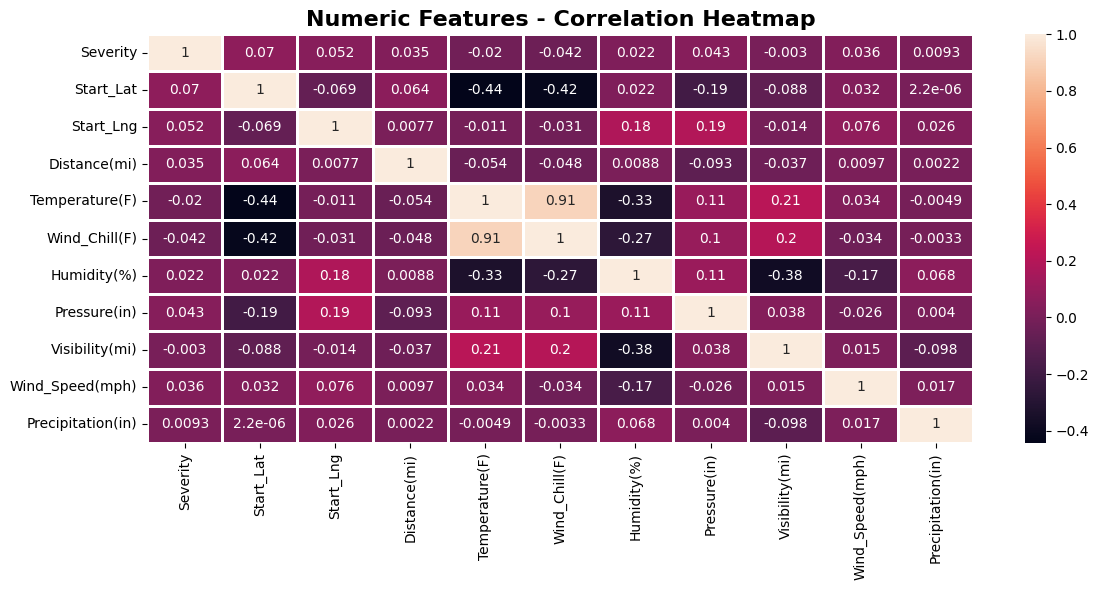

In [ ]:
# Visualising numeric feature correlation - Heatmap
us_numeric_type = Part_A_ds.select_dtypes(include=["int64", "float64"])

plt.figure(figsize= (12, 6))
sns.heatmap(us_numeric_type.corr(), annot=True, linewidths=1)
plt.title("Numeric Features - Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

#### Data Preprocessing

##### Outlier Treatment

In [ ]:
Part_A_ds.describe()

,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.597276e+06,7597276,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06
mean,2.212300e+00,2020-06-01 12:01:44.684660736,3.619215e+01,-9.468373e+01,5.578309e-01,6.167704e+01,5.917548e+01,6.484831e+01,2.954022e+01,9.097258e+00,7.644913e+00,6.104809e-03
min,1.000000e+00,2016-01-14 20:18:33,2.455480e+01,-1.246238e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2018-11-20 07:21:12.500000,3.338558e+01,-1.172087e+02,0.000000e+00,4.900000e+01,5.200000e+01,4.800000e+01,2.937000e+01,1.000000e+01,5.000000e+00,0.000000e+00
50%,2.000000e+00,2020-11-09 16:59:00,3.580487e+01,-8.776320e+01,2.800000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,2022-01-18 14:50:00,4.009566e+01,-8.036949e+01,4.590000e-01,7.600000e+01,7.100000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.000000e+01,0.000000e+00
max,4.000000e+00,2023-03-31 23:30:00,4.900220e+01,-6.711317e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01
std,4.870028e-01,NaN,5.092885e+00,1.736801e+01,1.767564e+00,1.896026e+01,1.949498e+01,2.273928e+01,1.004603e+00,2.679841e+00,5.263022e+00,9.405786e-02


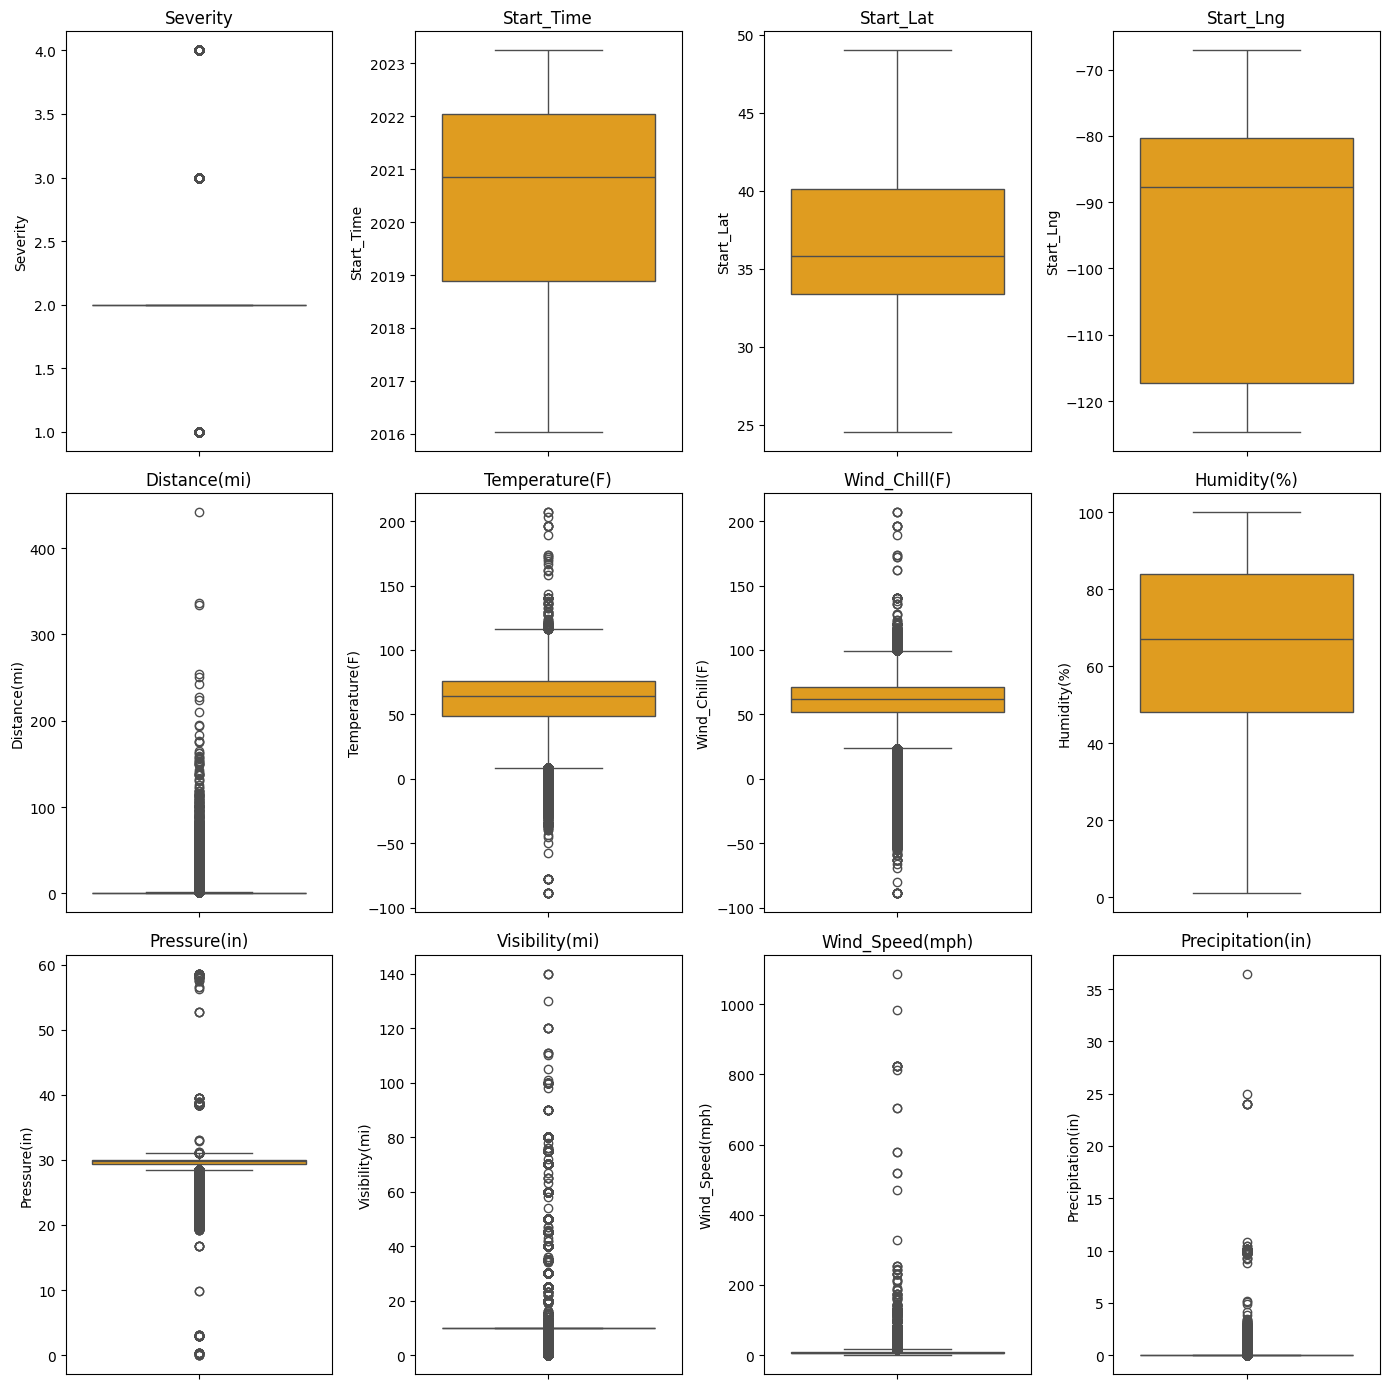

In [ ]:
plot_potential_outliers = ["Severity", "Start_Time", "Start_Lat", "Start_Lng", "Distance(mi)", "Temperature(F)",
                           "Wind_Chill(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]

fig, ax = plt.subplots(ncols=4, nrows=3, figsize=(14, 14))
ax_flat = ax.flatten()

for n, cols in enumerate(plot_potential_outliers):
    sns.boxplot(data=Part_A_ds, y=cols, ax=ax_flat[n], color="orange")
    ax_flat[n].set_title(cols)
plt.tight_layout()
plt.show()

In [ ]:
# Features: "Severity", "Start_Time", "Start_Lat", "Start_Lng", & "Humidity(%)" will not require any outlier treatment.
# However, features: "Distance(mi)", "Temperature(F)", "Wind_Chill(F)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"
# will need to outlier treatment

treatment_features = ["Distance(mi)", "Temperature(F)", "Wind_Chill(F)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]
for cols in treatment_features:
    low_val, upp_val = Part_A_ds[cols].quantile([0.01, 0.99])
    Part_A_ds[cols] = Part_A_ds[cols].clip(lower=low_val, upper=upp_val)

In [ ]:
Part_A_ds.describe()

,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.597276e+06,7597276,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06
mean,2.212300e+00,2020-06-01 12:01:44.684660736,3.619215e+01,-9.468373e+01,5.029359e-01,6.172287e+01,5.924769e+01,6.484831e+01,2.954748e+01,9.043848e+00,7.609194e+00,3.714660e-03
min,1.000000e+00,2016-01-14 20:18:33,2.455480e+01,-1.246238e+02,0.000000e+00,1.220000e+01,2.000000e+00,1.000000e+00,2.458000e+01,5.000000e-01,0.000000e+00,0.000000e+00
25%,2.000000e+00,2018-11-20 07:21:12.500000,3.338558e+01,-1.172087e+02,0.000000e+00,4.900000e+01,5.200000e+01,4.800000e+01,2.937000e+01,1.000000e+01,5.000000e+00,0.000000e+00
50%,2.000000e+00,2020-11-09 16:59:00,3.580487e+01,-8.776320e+01,2.800000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,2022-01-18 14:50:00,4.009566e+01,-8.036949e+01,4.590000e-01,7.600000e+01,7.100000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.000000e+01,0.000000e+00
max,4.000000e+00,2023-03-31 23:30:00,4.900220e+01,-6.711317e+01,6.918000e+00,9.600000e+01,9.400000e+01,1.000000e+02,3.044000e+01,1.000000e+01,2.300000e+01,1.400000e-01
std,4.870028e-01,NaN,5.092885e+00,1.736801e+01,1.125074e+00,1.861664e+01,1.898878e+01,2.273928e+01,9.486648e-01,2.320362e+00,4.980852e+00,1.837201e-02


##### Feature Engineering

In [ ]:
# Dropping feature that dont add value:"ID", "Country"
# ID - is unique identifier, which wont help with evaluation
# Country - the dataset values are collected from US, so this feature is redundant
# Description - there are other columns that provide more information with regards to the accident

Part_A_ds = Part_A_ds.drop(columns=["ID", "Country", "Description"])

In [ ]:
Part_A_ds.shape

(7597276, 41)

##### Feature Encoding

In [ ]:
Part_A_ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7597276 entries, 0 to 7728393
Data columns (total 41 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Source                 object        
 1   Severity               int64         
 2   Start_Time             datetime64[ns]
 3   End_Time               object        
 4   Start_Lat              float64       
 5   Start_Lng              float64       
 6   Distance(mi)           float64       
 7   Street                 object        
 8   City                   object        
 9   County                 object        
 10  State                  object        
 11  Zipcode                object        
 12  Timezone               object        
 13  Airport_Code           object        
 14  Weather_Timestamp      object        
 15  Temperature(F)         float64       
 16  Wind_Chill(F)          float64       
 17  Humidity(%)            float64       
 18  Pressure(in)           floa

In [ ]:
Part_A_ds["Start_Time"] = Part_A_ds["Start_Time"].astype(str)

In [ ]:
# bool & str/object will need to be categorised into numerical values

category_col = Part_A_ds.select_dtypes(include=["object", "bool"]).columns
print(category_col)

Index(['Source', 'Start_Time', 'End_Time', 'Street', 'City', 'County', 'State',
       'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp',
       'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')


In [ ]:
# Using label encoding to convert object & str dtypes into numerical dtypes
encode_cols = LabelEncoder()

for cols in category_col:
    Part_A_ds[cols] = encode_cols.fit_transform(Part_A_ds[cols])

In [ ]:
Part_A_ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7597276 entries, 0 to 7728393
Data columns (total 41 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Source                 int64  
 1   Severity               int64  
 2   Start_Time             int64  
 3   End_Time               int64  
 4   Start_Lat              float64
 5   Start_Lng              float64
 6   Distance(mi)           float64
 7   Street                 int64  
 8   City                   int64  
 9   County                 int64  
 10  State                  int64  
 11  Zipcode                int64  
 12  Timezone               int64  
 13  Airport_Code           int64  
 14  Weather_Timestamp      int64  
 15  Temperature(F)         float64
 16  Wind_Chill(F)          float64
 17  Humidity(%)            float64
 18  Pressure(in)           float64
 19  Visibility(mi)         float64
 20  Wind_Direction         int64  
 21  Wind_Speed(mph)        float64
 22  Precipitation(in)      

#### Model Training and Testing

In [ ]:
X = Part_A_ds.drop("Severity", axis=1).copy()
Y = Part_A_ds["Severity"].copy()

In [ ]:
Y.unique()

array([3, 2, 1, 4])

In [ ]:
# Subtracting 1 from y so that the severity label starts with 0
Y = Y - 1

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
# Apply standard scaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

##### Experimental Model 1 - ANN

In [ ]:
# Model 1 - ANN (Experiment)
def ann_1_experiment_model(num_classes = 4):
    model = tf.keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))
    # Adding hidden layers
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dense(num_classes, activation="softmax"))
    # Compiling the model
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model
# To train the model
model_building = ann_1_experiment_model()
model_history = model_building.fit(X_train, Y_train, validation_split=0.2, epochs=10, batch_size=256, callbacks=[tf.keras.callbacks.ReduceLROnPlateau()])

Epoch 1/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.8566 - loss: 0.3514 - val_accuracy: 0.8678 - val_loss: 0.3282 - learning_rate: 0.0010
Epoch 2/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.8705 - loss: 0.3220 - val_accuracy: 0.8718 - val_loss: 0.3189 - learning_rate: 0.0010
Epoch 3/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.8738 - loss: 0.3144 - val_accuracy: 0.8750 - val_loss: 0.3116 - learning_rate: 0.0010
Epoch 4/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.8756 - loss: 0.3103 - val_accuracy: 0.8761 - val_loss: 0.3103 - learning_rate: 0.0010
Epoch 5/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.8766 - loss: 0.3076 - val_accuracy: 0.8774 - val_loss: 0.3072 - learning_rate: 0.0010
Epoch 6/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.8776 - loss: 0.3054 - val_accuracy: 0.8781 - val_loss: 0.3043 - learning_rate: 0.0010
Epoch 7/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step -

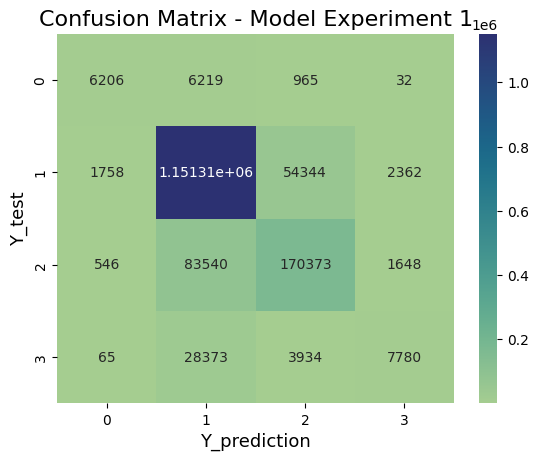

In [ ]:
# Getting models prediction
y_prob = model_building.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

#from this get the confusion matrix
model_confuse_mat = confusion_matrix(Y_test, y_pred)
sns.heatmap(model_confuse_mat, annot=True, fmt="g", cmap="crest")
plt.ylabel("Y_test", fontsize=13)
plt.xlabel("Y_prediction", fontsize=13)
plt.title("Confusion Matrix - Model Experiment 1", fontsize=16)
plt.show()

In [ ]:
# Also obtain the classification report
print("Model Experiment 1 (Classification report): ")
print(classification_report(Y_test, y_pred))

Model Experiment 1 (Classification report): 
              precision    recall  f1-score   support

           0       0.72      0.46      0.56     13422
           1       0.91      0.95      0.93   1209775
           2       0.74      0.67      0.70    256107
           3       0.66      0.19      0.30     40152

    accuracy                           0.88   1519456
   macro avg       0.76      0.57      0.62   1519456
weighted avg       0.87      0.88      0.87   1519456



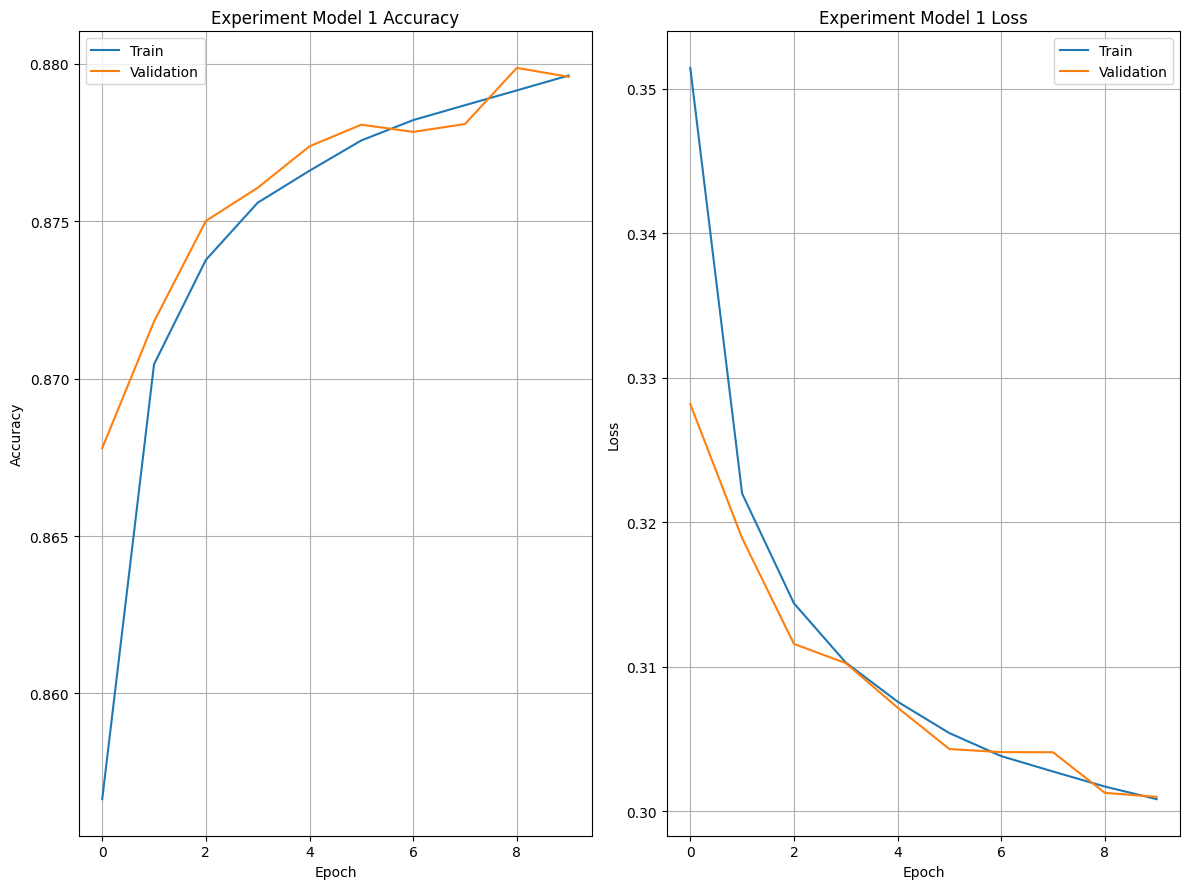

In [ ]:
# Plotting the Learning graph of Model 1
fig, (ax1, ax2) = plt.subplots(figsize=(12, 9), ncols=2, nrows=1)
ax1.plot(model_history.history["accuracy"], label="Train")
ax1.plot(model_history.history["val_accuracy"], label="Validation")
ax1.set_title("Experiment Model 1 Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid()

ax2.plot(model_history.history["loss"], label="Train")
ax2.plot(model_history.history["val_loss"], label="Validation")
ax2.set_title("Experiment Model 1 Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

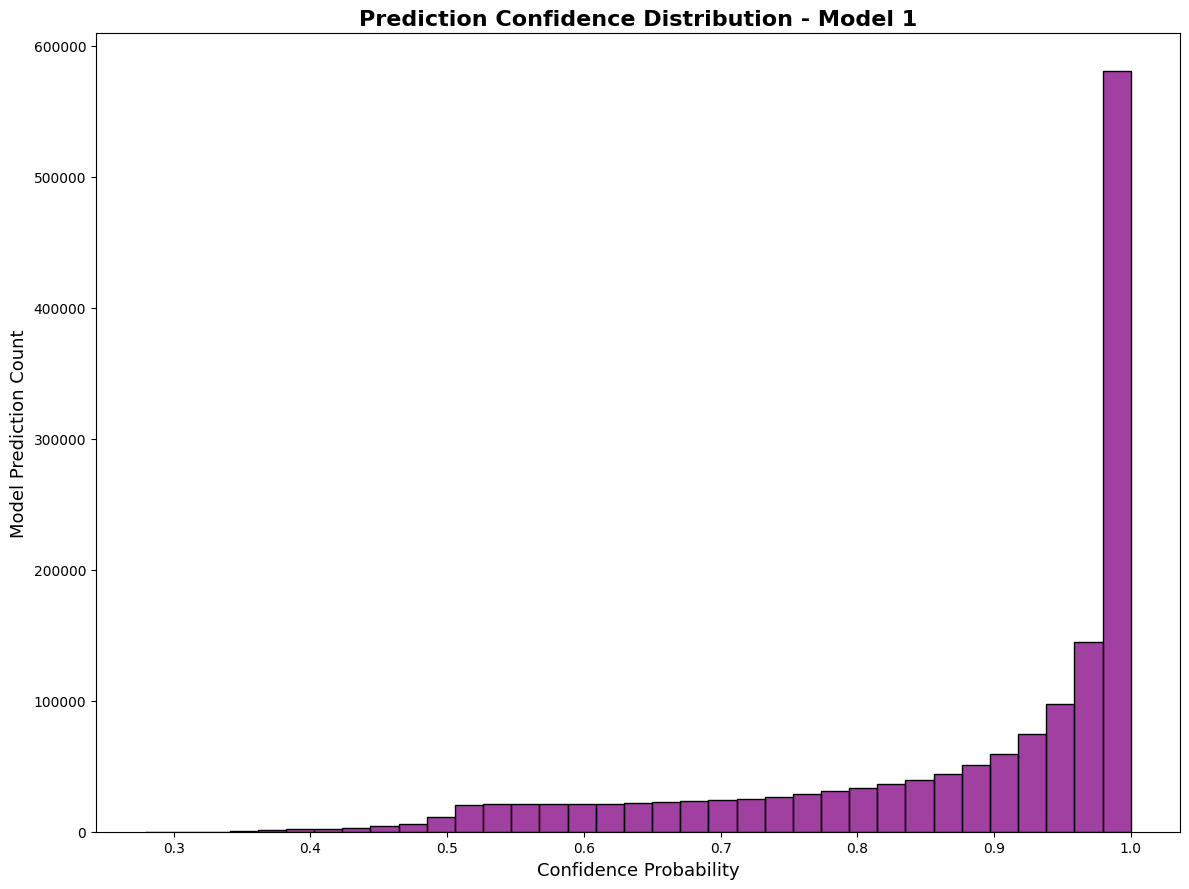

In [ ]:
# Obtain models prediction confidence - Model 1
y_pred = np.max(y_prob, axis=1)
convert_to_dataframe = pd.Series(y_pred)

# Plot the model prediction confidence
plt.figure(figsize=(12, 9))
sns.histplot(data=convert_to_dataframe, color="purple", bins=35)
plt.title("Prediction Confidence Distribution - Model 1", fontsize=16, fontweight="bold")
plt.xlabel("Confidence Probability", fontsize=13)
plt.ylabel("Model Prediction Count", fontsize=13)
plt.tight_layout()
plt.show()

##### Experimental Model 2 - ANN

In [ ]:
# Model 2 - ANN (Experiment)
def ann_2_experiment_model(num_classes = 4):
    model = tf.keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))
    # Adding hidden layers
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dense(num_classes, activation="softmax"))
    # Compiling the model
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model
# To train the model
model_building = ann_2_experiment_model()
model_history = model_building.fit(X_train, Y_train, validation_split=0.2, epochs=14, batch_size=256, callbacks=[tf.keras.callbacks.ReduceLROnPlateau()])

Epoch 1/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 52s 3ms/step - accuracy: 0.8555 - loss: 0.3529 - val_accuracy: 0.8715 - val_loss: 0.3187 - learning_rate: 0.0010
Epoch 2/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.8701 - loss: 0.3229 - val_accuracy: 0.8757 - val_loss: 0.3095 - learning_rate: 0.0010
Epoch 3/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 0.8729 - loss: 0.3162 - val_accuracy: 0.8775 - val_loss: 0.3064 - learning_rate: 0.0010
Epoch 4/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 0.8745 - loss: 0.3125 - val_accuracy: 0.8785 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 5/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.8757 - loss: 0.3098 - val_accuracy: 0.8797 - val_loss: 0.3007 - learning_rate: 0.0010
Epoch 6/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.8767 - loss: 0.3077 - val_accuracy: 0.8809 - val_loss: 0.2980 - learning_rate: 0.0010
Epoch 7/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step -

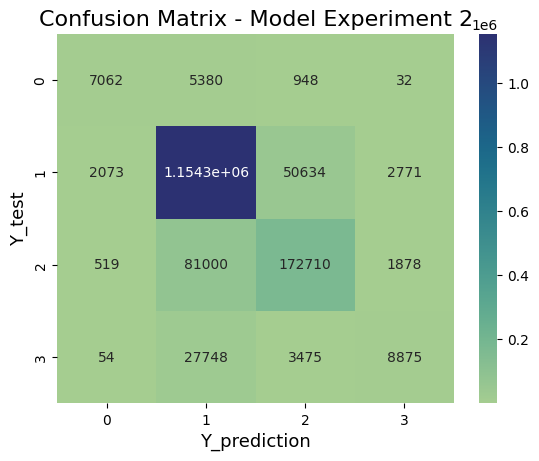

In [ ]:
# Getting models prediction
y_prob = model_building.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

#from this get the confusion matrix
model_confuse_mat = confusion_matrix(Y_test, y_pred)
sns.heatmap(model_confuse_mat, annot=True, fmt="g", cmap="crest")
plt.ylabel("Y_test", fontsize=13)
plt.xlabel("Y_prediction", fontsize=13)
plt.title("Confusion Matrix - Model Experiment 2", fontsize=16)
plt.show()

In [ ]:
# Also obtain the classification report
print("Model Experiment 2 (Classification report): ")
print(classification_report(Y_test, y_pred))

Model Experiment 2 (Classification report): 
              precision    recall  f1-score   support

           0       0.73      0.53      0.61     13422
           1       0.91      0.95      0.93   1209775
           2       0.76      0.67      0.71    256107
           3       0.65      0.22      0.33     40152

    accuracy                           0.88   1519456
   macro avg       0.76      0.59      0.65   1519456
weighted avg       0.88      0.88      0.88   1519456



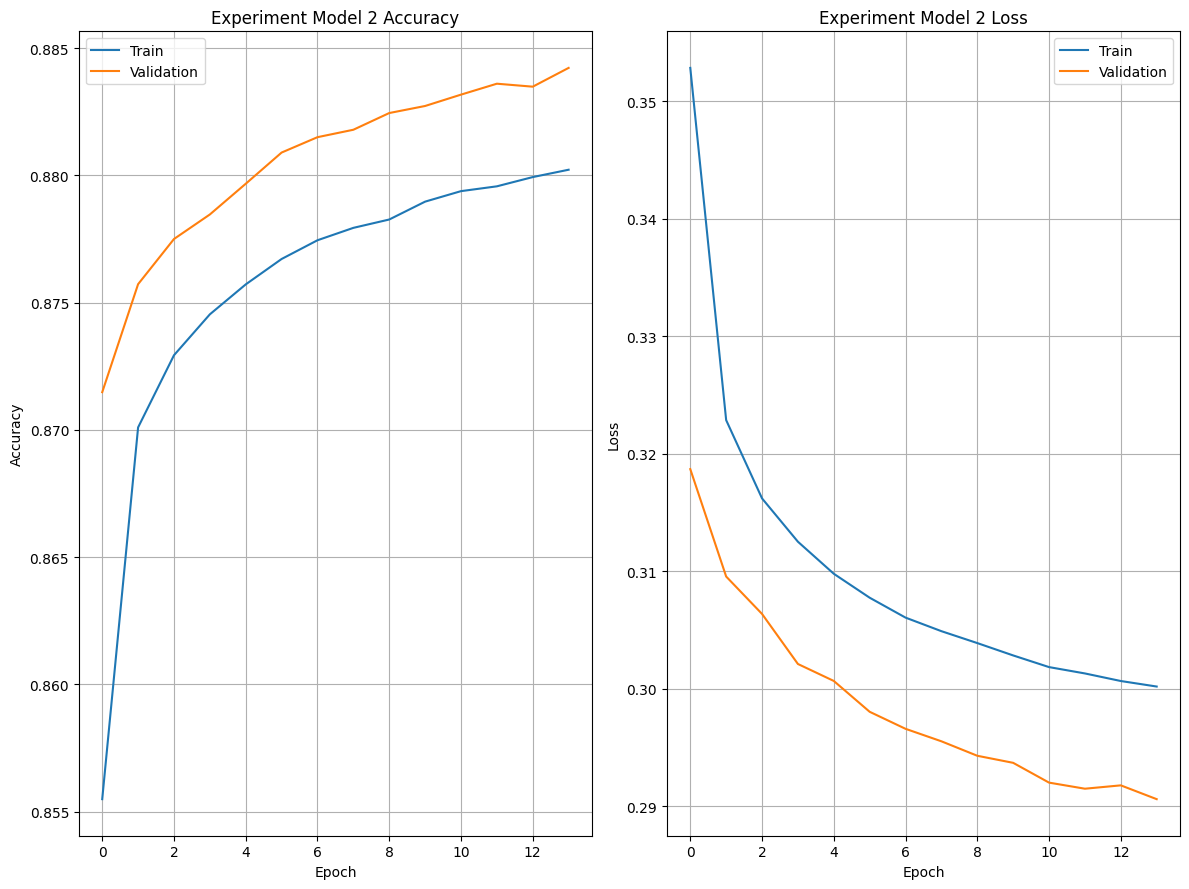

In [ ]:
# Plotting the Learning graph of Model 2
fig, (ax1, ax2) = plt.subplots(figsize=(12, 9), ncols=2, nrows=1)
ax1.plot(model_history.history["accuracy"], label="Train")
ax1.plot(model_history.history["val_accuracy"], label="Validation")
ax1.set_title("Experiment Model 2 Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid()

ax2.plot(model_history.history["loss"], label="Train")
ax2.plot(model_history.history["val_loss"], label="Validation")
ax2.set_title("Experiment Model 2 Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()


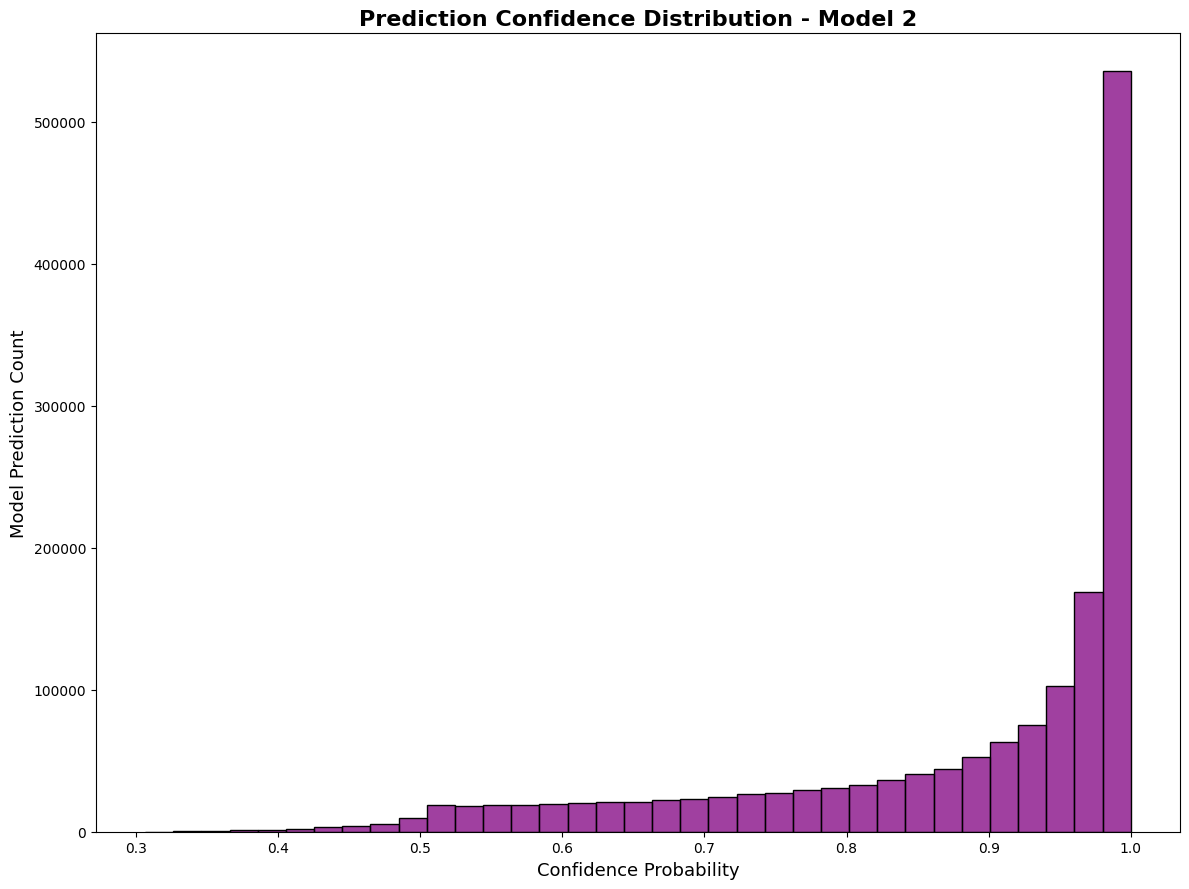

In [ ]:
# Obtain models prediction confidence - Model 2
y_pred = np.max(y_prob, axis=1)
convert_to_dataframe = pd.Series(y_pred)

# Plot the model prediction confidence
plt.figure(figsize=(12, 9))
sns.histplot(data=convert_to_dataframe, color="purple", bins=35)
plt.title("Prediction Confidence Distribution - Model 2", fontsize=16, fontweight="bold")
plt.xlabel("Confidence Probability", fontsize=13)
plt.ylabel("Model Prediction Count", fontsize=13)
plt.tight_layout()
plt.show()

##### Experimental Model 3 - ANN

In [ ]:
# Model 3 - ANN (Experiment)
def ann_3_experiment_model(num_classes = 4):
    model = tf.keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))
    # Adding hidden layers
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(num_classes, activation="softmax"))
    # Compiling the model
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model
# To train the model
model_building = ann_3_experiment_model()
model_history = model_building.fit(X_train, Y_train, validation_split=0.2, epochs=20, batch_size=256, callbacks=[tf.keras.callbacks.ReduceLROnPlateau()])

Epoch 1/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - accuracy: 0.8557 - loss: 0.3567 - val_accuracy: 0.8713 - val_loss: 0.3184 - learning_rate: 0.0010
Epoch 2/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - accuracy: 0.8687 - loss: 0.3285 - val_accuracy: 0.8746 - val_loss: 0.3102 - learning_rate: 0.0010
Epoch 3/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - accuracy: 0.8713 - loss: 0.3222 - val_accuracy: 0.8778 - val_loss: 0.3059 - learning_rate: 0.0010
Epoch 4/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - accuracy: 0.8730 - loss: 0.3186 - val_accuracy: 0.8795 - val_loss: 0.3022 - learning_rate: 0.0010
Epoch 5/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - accuracy: 0.8740 - loss: 0.3162 - val_accuracy: 0.8802 - val_loss: 0.2990 - learning_rate: 0.0010
Epoch 6/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - accuracy: 0.8749 - loss: 0.3143 - val_accuracy: 0.8820 - val_loss: 0.2965 - learning_rate: 0.0010
Epoch 7/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step -

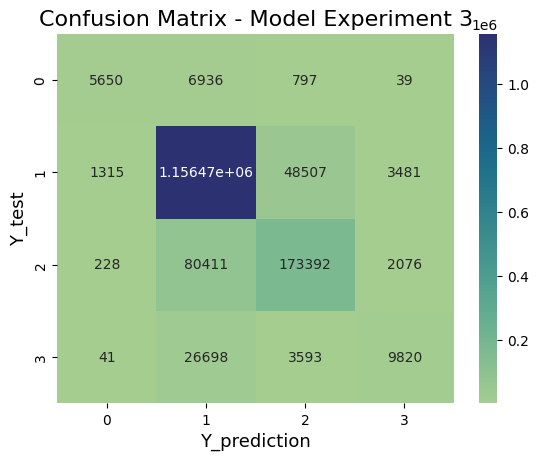

In [ ]:
# Getting models prediction
y_prob = model_building.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

#from this get the confusion matrix
model_confuse_mat = confusion_matrix(Y_test, y_pred)
sns.heatmap(model_confuse_mat, annot=True, fmt="g", cmap="crest")
plt.ylabel("Y_test", fontsize=13)
plt.xlabel("Y_prediction", fontsize=13)
plt.title("Confusion Matrix - Model Experiment 3", fontsize=16)
plt.show()

In [ ]:
# Also obtain the classification report
print("Model Experiment 3 (Classification report): ")
print(classification_report(Y_test, y_pred))

Model Experiment 3 (Classification report): 
              precision    recall  f1-score   support

           0       0.78      0.42      0.55     13422
           1       0.91      0.96      0.93   1209775
           2       0.77      0.68      0.72    256107
           3       0.64      0.24      0.35     40152

    accuracy                           0.89   1519456
   macro avg       0.77      0.57      0.64   1519456
weighted avg       0.88      0.89      0.88   1519456



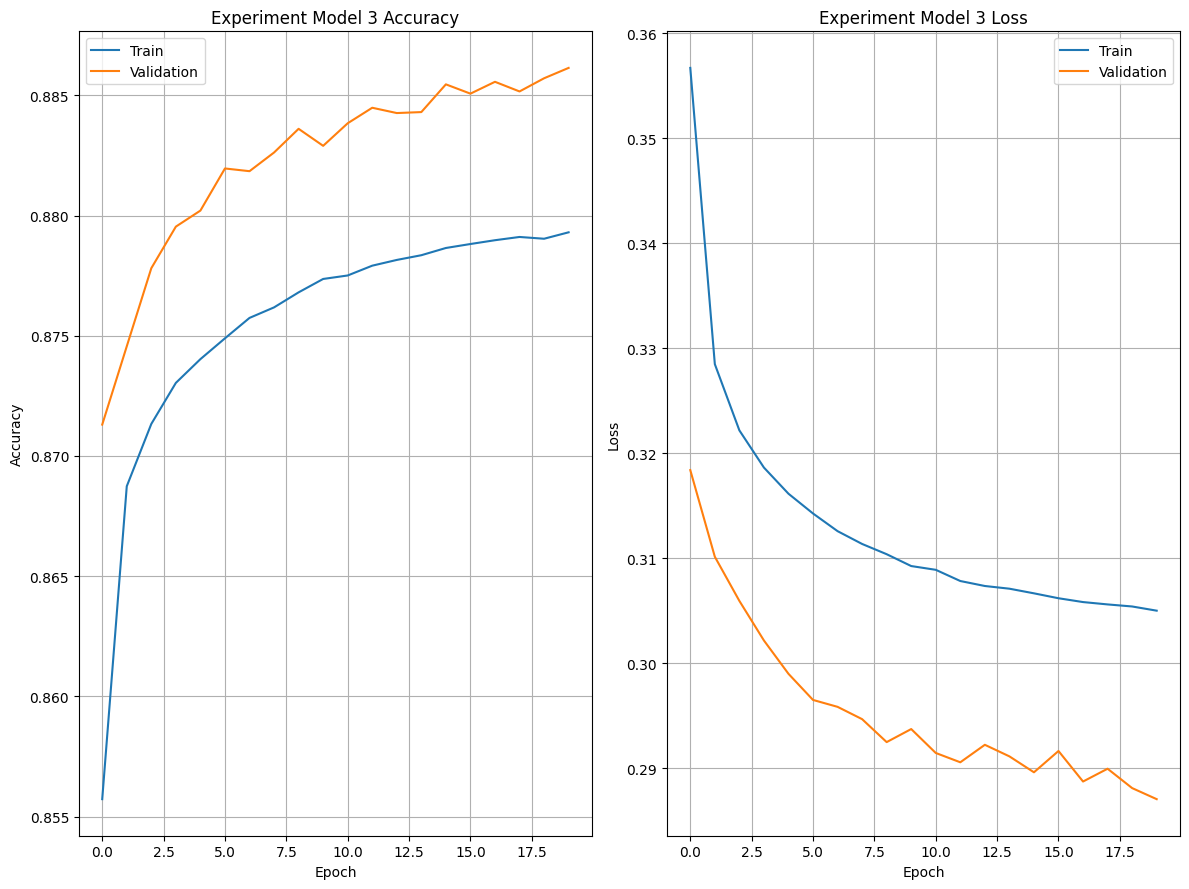

In [ ]:
# Plotting the Learning graph of Model 3
fig, (ax1, ax2) = plt.subplots(figsize=(12, 9), ncols=2, nrows=1)
ax1.plot(model_history.history["accuracy"], label="Train")
ax1.plot(model_history.history["val_accuracy"], label="Validation")
ax1.set_title("Experiment Model 3 Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid()

ax2.plot(model_history.history["loss"], label="Train")
ax2.plot(model_history.history["val_loss"], label="Validation")
ax2.set_title("Experiment Model 3 Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

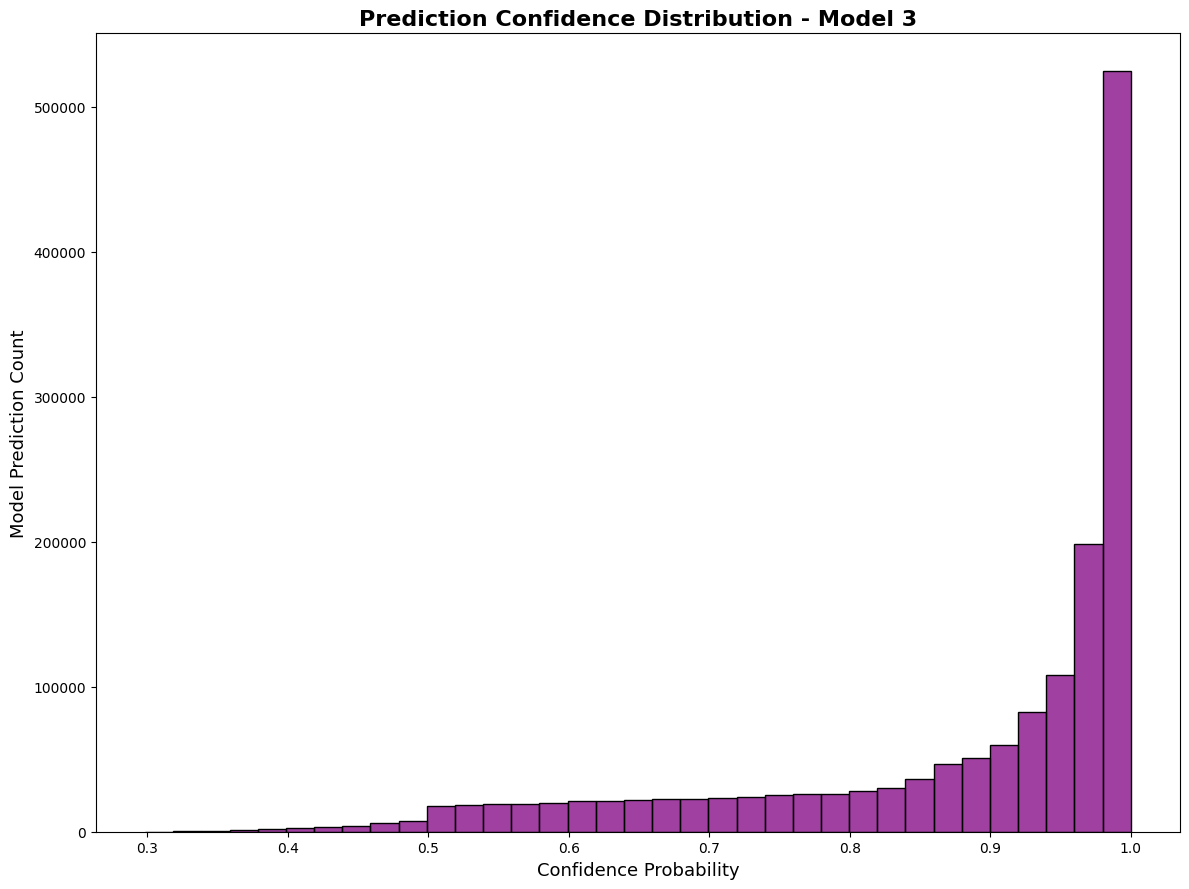

In [ ]:
# Obtain models prediction confidence - Model 3
y_pred = np.max(y_prob, axis=1)
convert_to_dataframe = pd.Series(y_pred)

# Plot the model prediction confidence
plt.figure(figsize=(12, 9))
sns.histplot(data=convert_to_dataframe, color="purple", bins=35)
plt.title("Prediction Confidence Distribution - Model 3", fontsize=16, fontweight="bold")
plt.xlabel("Confidence Probability", fontsize=13)
plt.ylabel("Model Prediction Count", fontsize=13)
plt.tight_layout()
plt.show()